In [25]:
import json
import os
from pprint import pprint

os.chdir('/Users/lockewang/FIG/WebDomainRandomizer/')
print(os.getcwd())

data_root = os.path.join("baseline_results", "multi_element_results")

results = {}
for folder in os.listdir(data_root):
    folder_path = os.path.join(data_root, folder)
    summary_file = os.path.join(folder_path, "uitars_summary.json")

    if not os.path.isdir(folder_path):
        continue  # skip non-directories

    if not os.path.isfile(summary_file):
        print(f"Warning: Missing {summary_file}")
        continue

    with open(summary_file, "r") as f:
        data = json.load(f)
    results["_".join(folder.split('_')[3:])] = data['global']['metrics']

pprint(sorted(results.items(), key=lambda x: x[0]))


/Users/lockewang/FIG/WebDomainRandomizer
[('test_domain_original',
  {'action_str_em': {'count': 116, 'mean': 0.853448275862069},
   'bbox_center_mse': {'count': 115, 'mean': 208396.10085285018},
   'hit_box_accuracy': {'count': 115, 'mean': 0.1565217391304348}}),
 ('test_domain_precision',
  {'action_str_em': {'count': 119, 'mean': 0.8403361344537815},
   'bbox_center_mse': {'count': 118, 'mean': 144261.26485350626},
   'hit_box_accuracy': {'count': 118, 'mean': 0.11864406779661017}}),
 ('test_domain_style',
  {'action_str_em': {'count': 116, 'mean': 0.8448275862068966},
   'bbox_center_mse': {'count': 114, 'mean': 201134.75401273323},
   'hit_box_accuracy': {'count': 114, 'mean': 0.18421052631578946}}),
 ('test_domain_text_shrink',
  {'action_str_em': {'count': 116, 'mean': 0.8275862068965517},
   'bbox_center_mse': {'count': 115, 'mean': 175499.11445754627},
   'hit_box_accuracy': {'count': 115, 'mean': 0.11304347826086956}}),
 ('test_task_original',
  {'action_str_em': {'count': 13

In [29]:
os.chdir('/Users/lockewang/FIG/WebDomainRandomizer/')
print(os.getcwd())

data_root = os.path.join("baseline_single_step_results/", "single_step_results")

results = {}
for folder in os.listdir(data_root):
    folder_path = os.path.join(data_root, folder)
    summary_file = os.path.join(folder_path, "uitars_summary.json")

    if not os.path.isdir(folder_path):
        continue  # skip non-directories

    if not os.path.isfile(summary_file):
        print(f"Warning: Missing {summary_file}")
        continue

    with open(summary_file, "r") as f:
        data = json.load(f)
    results["_".join(folder.split('_')[3:])] = data['global']['metrics']

pprint(sorted(results.items(), key=lambda x: x[0]))


/Users/lockewang/FIG/WebDomainRandomizer
[('test_domain_original',
  {'action_str_em': {'count': 116, 'mean': 0.8448275862068966},
   'bbox_center_mse': {'count': 113, 'mean': 196237.89222916958},
   'hit_box_accuracy': {'count': 113, 'mean': 0.5575221238938053}}),
 ('test_domain_precision',
  {'action_str_em': {'count': 119, 'mean': 0.8739495798319328},
   'bbox_center_mse': {'count': 119, 'mean': 96295.48831510419},
   'hit_box_accuracy': {'count': 119, 'mean': 0.5462184873949579}}),
 ('test_domain_style',
  {'action_str_em': {'count': 116, 'mean': 0.8362068965517241},
   'bbox_center_mse': {'count': 114, 'mean': 203761.09063254556},
   'hit_box_accuracy': {'count': 114, 'mean': 0.5789473684210527}}),
 ('test_domain_text_shrink',
  {'action_str_em': {'count': 116, 'mean': 0.8620689655172413},
   'bbox_center_mse': {'count': 113, 'mean': 163749.55417368966},
   'hit_box_accuracy': {'count': 113, 'mean': 0.5929203539823009}}),
 ('test_task_original',
  {'action_str_em': {'count': 130, 

# Results Analysis: L1 (Shallow) vs L2 (Deep Relational) Grounding

## Key Findings

### 1. **Massive Performance Gap: L1 vs L2**
- **L1 (Direct Element Pointing)**: Hit box accuracy: **41-59%**
- **L2 (Relational Queries)**: Hit box accuracy: **11-28%**
- **Drop**: ~3-4x worse performance on relational grounding tasks

**Interpretation**: The model struggles significantly with spatial reasoning. While it can find elements when directly referenced, it fails when spatial relationships are required.

### 2. **Action String EM vs Spatial Accuracy Disconnect**
- **Action String EM**: Similar between L1 (67-87%) and L2 (65-85%)
- **Hit Box Accuracy**: Dramatically different (L1: 41-59% vs L2: 11-28%)

**Interpretation**: The model can generate correct action strings (syntax) but fails at spatial localization (semantics). This suggests:
- The model understands *what* to do but not *where* to do it
- There's a fundamental gap between language understanding and visual-spatial reasoning

### 3. **Bounding Box MSE: Consistently High**
- **L1**: 96k-237k pixels² (best: precision variant at 96k)
- **L2**: 144k-316k pixels² (best: precision variant at 144k)

**Interpretation**: Even when the model "hits" the target, it's often far from the center. The high MSE suggests:
- Predictions are systematically off-target
- Precision variant (zoom) helps reduce error, suggesting scale sensitivity

### 4. **Variant Effects**

#### Precision (Zoom 70%) - **MOST HELPFUL**
- **L1**: Reduces bbox_center_mse by ~50% (196k → 96k for domain)
- **L2**: Reduces bbox_center_mse by ~30% (208k → 144k for domain)
- **Hit box accuracy**: Slightly worse in L2, similar in L1

**Interpretation**: Zoom helps with spatial precision, but doesn't solve relational reasoning.

#### Style Variant - **MIXED**
- **L1**: Slightly better hit box accuracy (57.9% vs 55.8% for domain)
- **L2**: Slightly better hit box accuracy (18.4% vs 15.7% for domain)
- **Bbox MSE**: Similar or worse

**Interpretation**: Style changes don't significantly hurt performance, suggesting the model isn't overly dependent on exact visual appearance.

#### Text Shrink (OCR Stress) - **MIXED**
- **L1**: Best hit box accuracy for domain (59.3%)
- **L2**: Worse hit box accuracy (11.3% vs 15.7% for domain)
- **Bbox MSE**: Moderate improvement

**Interpretation**: OCR degradation hurts relational reasoning more than direct pointing, suggesting text recognition is critical for understanding spatial relationships.

### 5. **Generalization Hierarchy**
Performance generally: **test_domain > test_task > test_website**

- **test_domain**: Best performance (e.g., L1 hit: 55-59%, L2 hit: 12-18%)
- **test_task**: Moderate (e.g., L1 hit: 43-49%, L2 hit: 11-18%)
- **test_website**: Worst (e.g., L1 hit: 41-53%, L2 hit: 16-28%)

**Interpretation**: The model generalizes better at domain level than task/website level, suggesting it learns domain-specific patterns but struggles with novel tasks/websites.

### 6. **Critical Failure Mode: Relational Grounding**
- **L2 hit box accuracy**: Only 11-28% success rate
- Even with correct action strings (65-85% EM), spatial localization fails

**Interpretation**: This is the core weakness - the model cannot reliably:
1. Identify the reference element ("google searchbox")
2. Understand spatial relationships ("above", "below", "to the left")
3. Locate the target element based on that relationship

## Research Implications

1. **Spatial Reasoning is the Bottleneck**: The model needs significant improvement in understanding spatial relationships between UI elements.

2. **Action String ≠ Success**: High action string EM is misleading - it doesn't guarantee correct execution.

3. **Precision Matters**: Zoom/scale affects performance, suggesting the model needs better multi-scale reasoning.

4. **Text is Critical for Relations**: OCR degradation hurts L2 more than L1, suggesting text understanding is key for relational queries.

5. **Generalization Challenge**: Performance degrades with generalization level (domain → task → website), indicating overfitting to training patterns.


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load both datasets
single_step_root = "baseline_single_step_results/single_step_results"
multi_element_root = "baseline_results/multi_element_results"

def load_results(data_root):
    results = {}
    for folder in os.listdir(data_root):
        folder_path = os.path.join(data_root, folder)
        summary_file = os.path.join(folder_path, "uitars_summary.json")
        
        if not os.path.isdir(folder_path) or not os.path.isfile(summary_file):
            continue
            
        with open(summary_file, "r") as f:
            data = json.load(f)
        results["_".join(folder.split('_')[3:])] = data['global']['metrics']
    return results

l1_results = load_results(single_step_root)
l2_results = load_results(multi_element_root)

# Create comparison DataFrame
comparison_data = []
for split_name in sorted(set(list(l1_results.keys()) + list(l2_results.keys()))):
    if split_name in l1_results and split_name in l2_results:
        l1 = l1_results[split_name]
        l2 = l2_results[split_name]
        
        comparison_data.append({
            'split': split_name,
            'l1_hit_accuracy': l1['hit_box_accuracy']['mean'],
            'l2_hit_accuracy': l2['hit_box_accuracy']['mean'],
            'l1_bbox_mse': l1['bbox_center_mse']['mean'],
            'l2_bbox_mse': l2['bbox_center_mse']['mean'],
            'l1_action_em': l1['action_str_em']['mean'],
            'l2_action_em': l2['action_str_em']['mean'],
        })

df = pd.DataFrame(comparison_data)

# Calculate performance gap
df['hit_accuracy_gap'] = df['l1_hit_accuracy'] - df['l2_hit_accuracy']
df['bbox_mse_ratio'] = df['l2_bbox_mse'] / df['l1_bbox_mse']

print("=" * 80)
print("L1 vs L2 Performance Comparison")
print("=" * 80)
print(f"\nAverage Hit Box Accuracy:")
print(f"  L1 (Direct): {df['l1_hit_accuracy'].mean():.1%}")
print(f"  L2 (Relational): {df['l2_hit_accuracy'].mean():.1%}")
print(f"  Gap: {df['hit_accuracy_gap'].mean():.1%} ({df['hit_accuracy_gap'].mean() / df['l2_hit_accuracy'].mean():.1f}x worse)")

print(f"\nAverage BBox Center MSE:")
print(f"  L1: {df['l1_bbox_mse'].mean():.0f} pixels²")
print(f"  L2: {df['l2_bbox_mse'].mean():.0f} pixels²")
print(f"  Ratio: {df['bbox_mse_ratio'].mean():.2f}x")

print(f"\nAverage Action String EM:")
print(f"  L1: {df['l1_action_em'].mean():.1%}")
print(f"  L2: {df['l2_action_em'].mean():.1%}")
print(f"  Difference: {(df['l1_action_em'].mean() - df['l2_action_em'].mean()):.1%}")

print("\n" + "=" * 80)
print("By Split Type:")
print("=" * 80)
for split_type in ['domain', 'task', 'website']:
    subset = df[df['split'].str.contains(split_type)]
    if len(subset) > 0:
        print(f"\n{split_type.upper()}:")
        print(f"  L1 Hit: {subset['l1_hit_accuracy'].mean():.1%} | L2 Hit: {subset['l2_hit_accuracy'].mean():.1%}")
        print(f"  L1 MSE: {subset['l1_bbox_mse'].mean():.0f} | L2 MSE: {subset['l2_bbox_mse'].mean():.0f}")

print("\n" + "=" * 80)
print("By Variant:")
print("=" * 80)
for variant in ['original', 'precision', 'style', 'text_shrink']:
    subset = df[df['split'].str.contains(variant)]
    if len(subset) > 0:
        print(f"\n{variant.upper()}:")
        print(f"  L1 Hit: {subset['l1_hit_accuracy'].mean():.1%} | L2 Hit: {subset['l2_hit_accuracy'].mean():.1%}")
        print(f"  L1 MSE: {subset['l1_bbox_mse'].mean():.0f} | L2 MSE: {subset['l2_bbox_mse'].mean():.0f}")

df


L1 vs L2 Performance Comparison

Average Hit Box Accuracy:
  L1 (Direct): 50.8%
  L2 (Relational): 16.3%
  Gap: 34.5% (2.1x worse)

Average BBox Center MSE:
  L1: 190743 pixels²
  L2: 230281 pixels²
  Ratio: 1.22x

Average Action String EM:
  L1: 77.8%
  L2: 77.0%
  Difference: 0.8%

By Split Type:

DOMAIN:
  L1 Hit: 56.9% | L2 Hit: 14.3%
  L1 MSE: 165011 | L2 MSE: 182323

TASK:
  L1 Hit: 46.6% | L2 Hit: 14.6%
  L1 MSE: 215287 | L2 MSE: 261153

WEBSITE:
  L1 Hit: 48.1% | L2 Hit: 21.1%
  L1 MSE: 192327 | L2 MSE: 253061

By Variant:

ORIGINAL:
  L1 Hit: 50.9% | L2 Hit: 17.9%
  L1 MSE: 219349 | L2 MSE: 249245

PRECISION:
  L1 Hit: 47.5% | L2 Hit: 13.0%
  L1 MSE: 156765 | L2 MSE: 202712

STYLE:
  L1 Hit: 51.5% | L2 Hit: 20.2%
  L1 MSE: 201418 | L2 MSE: 241924

TEXT_SHRINK:
  L1 Hit: 54.2% | L2 Hit: 12.7%
  L1 MSE: 182789 | L2 MSE: 225723


,split,l1_hit_accuracy,l2_hit_accuracy,l1_bbox_mse,l2_bbox_mse,l1_action_em,l2_action_em,hit_accuracy_gap,bbox_mse_ratio
0,test_domain_original,0.557522,0.156522,196237.892229,208396.100853,0.844828,0.853448,0.401000,1.061956
1,test_domain_precision,0.546218,0.118644,96295.488315,144261.264854,0.873950,0.840336,0.427574,1.498110
2,test_domain_style,0.578947,0.184211,203761.090633,201134.754013,0.836207,0.844828,0.394737,0.987111
3,test_domain_text_shrink,0.592920,0.113043,163749.554174,175499.114458,0.862069,0.827586,0.479877,1.071753
4,test_task_original,0.468750,0.184615,237463.629950,264264.773864,0.792308,0.769231,0.284135,1.112864
5,test_task_precision,0.468254,0.111111,191857.863944,188163.090934,0.781250,0.789062,0.357143,0.980742
6,test_task_style,0.435484,0.146341,229996.915051,316239.037371,0.761905,0.761905,0.289142,1.374971
7,test_task_text_shrink,0.491935,0.141732,201828.031310,275946.816301,0.779528,0.779528,0.350203,1.367237
8,test_website_original,0.500000,0.196078,224345.338410,275074.328325,0.673077,0.692308,0.303922,1.226120
9,test_website_precision,0.411765,0.160000,182140.927120,275711.522927,0.666667,0.666667,0.251765,1.513726


# Experimental Design Questions

## 1. Multiple Seeds: Necessary or Unnecessary?

### Current Signal Strength
- **L1 vs L2 gap**: 3-4x performance difference (41-59% vs 11-28%)
- **Consistency**: Results are consistent across all variants and splits
- **Effect size**: Very large - not a borderline case

### Recommendation: **LOW PRIORITY**
- The signal is already **very clear** - relational grounding fails dramatically
- Multiple seeds would help with:
  - Statistical significance testing (p-values, confidence intervals)
  - Understanding variance in model performance
  - Publication rigor
- But won't change the **qualitative conclusion**: spatial reasoning is broken

**Verdict**: Skip for now unless you need statistical rigor for publication. The effect is too large to be a fluke.

---

## 2. More Data: Needed?

### Current Sample Sizes
- **test_domain**: ~116-119 samples/variant × 4 = ~464 samples
- **test_task**: ~126-130 samples/variant × 4 = ~512 samples  
- **test_website**: ~47-52 samples/variant × 4 = ~200 samples ⚠️

### Issues
1. **test_website is small** (~50 samples/variant) - low statistical power
2. **High variance splits** - website split shows inconsistent patterns
3. **But**: The core finding (L2 failure) is consistent across all splits

### Recommendation: **CONDITIONAL**
- **If goal is to understand L1 vs L2 gap**: Current data is sufficient
- **If goal is to understand split-specific effects**: Need more website samples
- **If goal is to train better models**: More data always helps, but won't fix fundamental spatial reasoning issue

**Verdict**: Current data is sufficient for diagnostic purposes. More data would help with:
- Better website-level generalization analysis
- Training improved models
- But won't change the core finding

---

## 3. Split Meaningfulness: Critical Issue ⚠️

### The Problem
You're absolutely right: **Domain/Task/Website splits are episode-level, not step-level**

For step-wise grounding:
- **test_domain**: New domains, but steps might reuse common UI patterns (buttons, forms, etc.)
- **test_task**: New tasks, but steps might have similar layouts
- **test_website**: New websites, but steps might share design patterns

### What the Splits Actually Test
- **test_domain**: Can model ground elements in new domains? (But UI patterns are similar)
- **test_task**: Can model ground elements in new task contexts? (But steps are similar)
- **test_website**: Can model ground elements on new websites? (But layouts might be similar)

### Better Splits for Step-Wise Grounding
Consider splitting by:
1. **UI element types**: Button-heavy vs form-heavy vs navigation-heavy
2. **Spatial relationship complexity**: Simple (above/below) vs complex (diagonal, nested)
3. **Visual complexity**: Simple layouts vs cluttered/dense layouts
4. **Text density**: Text-rich vs icon-heavy
5. **Element rarity**: Common elements (buttons) vs rare elements (custom widgets)

### Recommendation: **HIGH PRIORITY**
- Current splits may be **confounding** your analysis
- The domain > task > website hierarchy might reflect:
  - Different UI pattern distributions, not true generalization
  - Different difficulty levels, not generalization gaps
- Consider **re-analyzing by step characteristics** rather than episode-level splits

**Verdict**: The splits are probably not testing what you think they're testing. Consider alternative split strategies or at least acknowledge this limitation.


In [31]:
# Alternative Analysis: By Step Characteristics (More Meaningful for Step-Wise Grounding)

# This would require loading the actual step data and analyzing by:
# - Spatial relationship type (above, below, left, right, etc.)
# - Reference element type (button, text, input, etc.)
# - Target element type
# - Visual complexity metrics
# - Text density
# - Layout density

print("To do a more meaningful analysis, you would need to:")
print("1. Load individual step data (not just aggregated metrics)")
print("2. Extract step-level characteristics:")
print("   - Spatial relationship type from multi_element_instruction")
print("   - Element types (button, input, text, etc.)")
print("   - Visual complexity (number of elements, layout density)")
print("   - Text vs icon ratio")
print("3. Group by these characteristics instead of episode-level splits")
print("4. Compare L1 vs L2 performance within each characteristic group")
print("\nThis would reveal:")
print("- Which spatial relationships are hardest?")
print("- Does element type matter?")
print("- Does visual complexity affect performance?")
print("- Are there systematic failure patterns?")

# Example: You could analyze by spatial relationship type
# relationships = ['above', 'below', 'left', 'right', 'near', 'inside', etc.]
# For each relationship type, compare L1 vs L2 performance


To do a more meaningful analysis, you would need to:
1. Load individual step data (not just aggregated metrics)
2. Extract step-level characteristics:
   - Spatial relationship type from multi_element_instruction
   - Element types (button, input, text, etc.)
   - Visual complexity (number of elements, layout density)
   - Text vs icon ratio
3. Group by these characteristics instead of episode-level splits
4. Compare L1 vs L2 performance within each characteristic group

This would reveal:
- Which spatial relationships are hardest?
- Does element type matter?
- Does visual complexity affect performance?
- Are there systematic failure patterns?


In [32]:
# Fine-Grained Step-Level Analysis
# Load individual step data and extract meaningful characteristics

import re
from collections import defaultdict
from pathlib import Path

def extract_spatial_relationship(instruction):
    """Extract spatial relationship keywords from instruction."""
    if not instruction:
        return None
    
    instruction_lower = instruction.lower()
    
    # Common spatial relationship patterns
    relationships = {
        'above': ['above', 'over', 'on top of', 'upper'],
        'below': ['below', 'under', 'underneath', 'beneath', 'lower'],
        'left': ['left of', 'to the left', 'left'],
        'right': ['right of', 'to the right', 'right'],
        'near': ['near', 'next to', 'beside', 'adjacent'],
        'inside': ['inside', 'within', 'in'],
        'between': ['between', 'among'],
    }
    
    for rel_type, keywords in relationships.items():
        for keyword in keywords:
            if keyword in instruction_lower:
                return rel_type
    
    return None

def extract_operation_type(op):
    """Normalize operation type."""
    if not op:
        return 'UNKNOWN'
    return op.upper()

def extract_reference_element(instruction):
    """Extract reference element mention from multi_element_instruction."""
    if not instruction:
        return None
    
    # Look for patterns like "above 'X'", "below 'Y'", etc.
    # This is a simple heuristic - can be improved
    patterns = [
        r"(?:above|below|left|right|near|inside|between)\s+['\"]([^'\"]+)['\"]",
        r"(?:above|below|left|right|near|inside|between)\s+([A-Z][^,\.]+?)(?:[,\.]|$)",
    ]
    
    for pattern in patterns:
        match = re.search(pattern, instruction, re.IGNORECASE)
        if match:
            return match.group(1).strip()
    
    return None

def load_step_data(data_root, level_name):
    """Load all step-level data from uitars_metrics.jsonl files."""
    all_steps = []
    
    for folder in os.listdir(data_root):
        folder_path = os.path.join(data_root, folder)
        metrics_file = os.path.join(folder_path, "uitars_metrics.jsonl")
        summary_file = os.path.join(folder_path, "uitars_summary.json")
        
        if not os.path.isdir(folder_path) or not os.path.isfile(metrics_file):
            continue
        
        # Extract split and variant from folder name
        parts = folder.split('_')
        if len(parts) < 3:
            continue
        
        split_variant = "_".join(parts[3:])  # e.g., "test_domain_original"
        
        # Also load summary to get instruction text
        summary_data = None
        if os.path.isfile(summary_file):
            with open(summary_file, 'r') as f:
                summary_data = json.load(f)
        
        # Create instruction lookup from summary
        instruction_lookup = {}
        if summary_data and 'episodes' in summary_data:
            for episode in summary_data['episodes']:
                episode_id = episode['episode']
                for step in episode.get('steps', []):
                    key = (episode_id, step['step_index'])
                    instruction_lookup[key] = step.get('instruction', '')
        
        # Load step-level metrics
        with open(metrics_file, 'r') as f:
            for line in f:
                if line.strip():
                    step_data = json.loads(line)
                    
                    # Get instruction from lookup or use empty
                    key = (step_data['episode'], step_data['step_index'])
                    instruction = instruction_lookup.get(key, '')
                    
                    # Extract characteristics
                    spatial_rel = extract_spatial_relationship(instruction) if level_name == 'L2' else None
                    ref_element = extract_reference_element(instruction) if level_name == 'L2' else None
                    
                    all_steps.append({
                        'level': level_name,
                        'split_variant': split_variant,
                        'episode': step_data['episode'],
                        'step_index': step_data['step_index'],
                        'op': extract_operation_type(step_data.get('op', '')),
                        'instruction': instruction,
                        'spatial_relationship': spatial_rel,
                        'reference_element': ref_element,
                        'action_str_em': step_data['metrics']['action_str_em'],
                        'hit_box_accuracy': step_data['metrics']['hit_box_accuracy'],
                        'bbox_center_mse': step_data['metrics']['bbox_center_mse'],
                    })
    
    return pd.DataFrame(all_steps)

print("Loading L1 (single_step) step-level data...")
l1_steps_df = load_step_data("baseline_single_step_results/single_step_results", "L1")

print("Loading L2 (multi_element) step-level data...")
l2_steps_df = load_step_data("baseline_results/multi_element_results", "L2")

print(f"\nLoaded {len(l1_steps_df)} L1 steps and {len(l2_steps_df)} L2 steps")

# Combine for analysis
all_steps_df = pd.concat([l1_steps_df, l2_steps_df], ignore_index=True)

# Extract split type and variant
all_steps_df['split_type'] = all_steps_df['split_variant'].str.extract(r'(test_domain|test_task|test_website)')
all_steps_df['variant'] = all_steps_df['split_variant'].str.extract(r'(original|precision|style|text_shrink)$')

print("\nData loaded successfully!")
print(f"Columns: {list(all_steps_df.columns)}")
print(f"\nSample rows:")
all_steps_df.head(10)


Loading L1 (single_step) step-level data...
Loading L2 (multi_element) step-level data...

Loaded 1168 L1 steps and 1184 L2 steps

Data loaded successfully!
Columns: ['level', 'split_variant', 'episode', 'step_index', 'op', 'instruction', 'spatial_relationship', 'reference_element', 'action_str_em', 'hit_box_accuracy', 'bbox_center_mse', 'split_type', 'variant']

Sample rows:


,level,split_variant,episode,step_index,op,instruction,spatial_relationship,reference_element,action_str_em,hit_box_accuracy,bbox_center_mse,split_type,variant
0,L1,test_task_text_shrink,012446b3-ee30-480b-86ec-3a3cdeaba9dc,0,CLICK,"Click on 'May 10th, 2023' button",None,None,1.0,1.0,5.552789,test_task,text_shrink
1,L1,test_task_text_shrink,012446b3-ee30-480b-86ec-3a3cdeaba9dc,1,CLICK,Click on 'Cooking' button,None,None,0.0,NaN,NaN,test_task,text_shrink
2,L1,test_task_text_shrink,03fd47fc-8412-487a-b895-26c80a95c398,0,CLICK,Click on 'PC Builder' link,None,None,1.0,1.0,11.240524,test_task,text_shrink
3,L1,test_task_text_shrink,0572899e-7c07-4a2f-a77b-bba4f432a7ad,0,CLICK,Type 'Joe' in '' input,None,None,1.0,0.0,142332.337264,test_task,text_shrink
4,L1,test_task_text_shrink,0de53aa5-cb8f-4789-b621-14262a4d5aae,0,CLICK,Click on 'Show flights' button,None,None,1.0,1.0,39.773834,test_task,text_shrink
5,L1,test_task_text_shrink,14d50319-3f81-4aa6-8ee8-d1b66e4d5d64,0,TYPE,Click on 'ADD TO LIST' link,None,None,0.0,1.0,26178.219681,test_task,text_shrink
6,L1,test_task_text_shrink,150146b2-ae80-4760-b2a9-1c7475ce5de2,0,CLICK,Click on 'Shop by Brand' link,None,None,1.0,1.0,82.817315,test_task,text_shrink
7,L1,test_task_text_shrink,18fc60d7-aa69-4c07-9bf1-64543eae52c9,0,TYPE,Type 'buckeye.foobar@gmail.com' in 'Email' input,None,None,0.0,0.0,7242.251378,test_task,text_shrink
8,L1,test_task_text_shrink,18fc60d7-aa69-4c07-9bf1-64543eae52c9,1,CLICK,Click on 'Recipient's Name' textbox,None,None,1.0,0.0,28609.779454,test_task,text_shrink
9,L1,test_task_text_shrink,19b955ba-fdcd-4345-b33a-fc6a88b5a85d,0,CLICK,Click on 'Apply now' link,None,None,1.0,1.0,18.650688,test_task,text_shrink


Analysis 1: L2 Performance by Spatial Relationship Type

Hit Box Accuracy by Spatial Relationship:
                      hit_box_accuracy_mean  hit_box_accuracy_count  hit_box_accuracy_std
spatial_relationship                                                                     
below                                0.1866                     284                0.3903
right                                0.1866                     134                0.3910
left                                 0.1800                     150                0.3855
above                                0.1254                     590                0.3315


BBox Center MSE by Spatial Relationship:
                      bbox_center_mse_mean  bbox_center_mse_std
spatial_relationship                                           
below                          237872.3347          535302.9242
right                          301158.5290          470852.6355
left                           254533.3477          517957.960

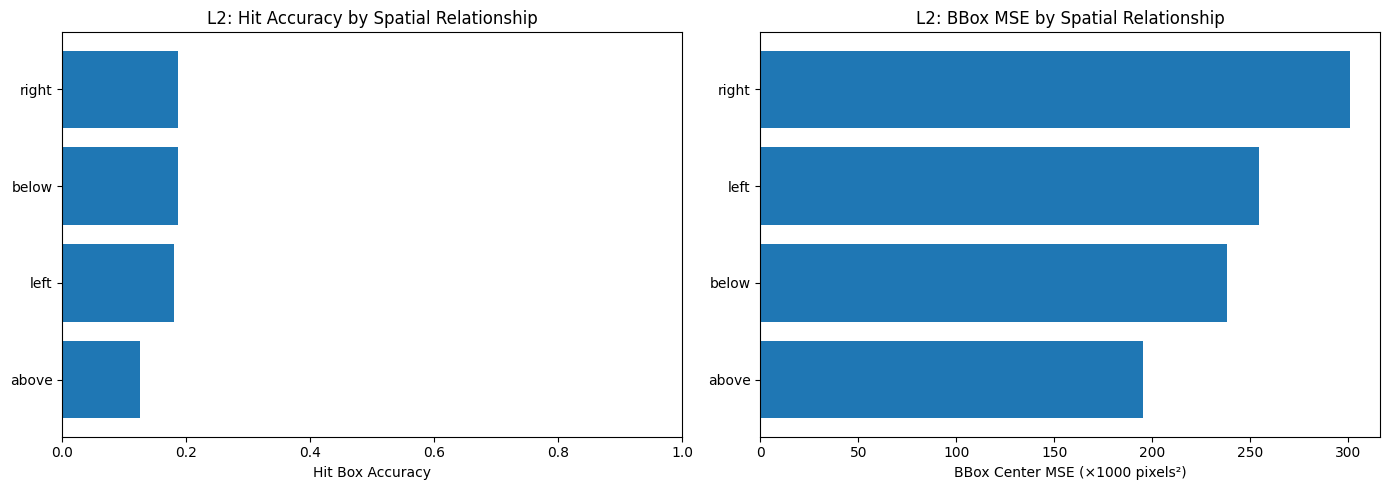

,hit_box_accuracy_mean,hit_box_accuracy_count,hit_box_accuracy_std,bbox_center_mse_mean,bbox_center_mse_std,action_str_em_mean,action_str_em_std
spatial_relationship,,,,,,,
below,0.1866,284,0.3903,237872.3347,535302.9242,0.7543,0.4312
right,0.1866,134,0.3910,301158.5290,470852.6355,0.7481,0.4357
left,0.1800,150,0.3855,254533.3477,517957.9601,0.8421,0.3658
above,0.1254,590,0.3315,195457.0012,414812.7622,0.7917,0.4065


In [33]:
# Analysis 1: Performance by Spatial Relationship Type (L2 only)

print("=" * 80)
print("Analysis 1: L2 Performance by Spatial Relationship Type")
print("=" * 80)

l2_only = all_steps_df[all_steps_df['level'] == 'L2'].copy()
spatial_analysis = l2_only.groupby('spatial_relationship').agg({
    'hit_box_accuracy': ['mean', 'count', 'std'],
    'bbox_center_mse': ['mean', 'std'],
    'action_str_em': ['mean', 'std'],
}).round(4)

spatial_analysis.columns = ['_'.join(col).strip() for col in spatial_analysis.columns.values]
spatial_analysis = spatial_analysis.sort_values('hit_box_accuracy_mean', ascending=False)

print("\nHit Box Accuracy by Spatial Relationship:")
print(spatial_analysis[['hit_box_accuracy_mean', 'hit_box_accuracy_count', 'hit_box_accuracy_std']].to_string())

print("\n\nBBox Center MSE by Spatial Relationship:")
print(spatial_analysis[['bbox_center_mse_mean', 'bbox_center_mse_std']].to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hit accuracy by relationship
spatial_analysis_sorted = spatial_analysis.sort_values('hit_box_accuracy_mean', ascending=True)
axes[0].barh(spatial_analysis_sorted.index, spatial_analysis_sorted['hit_box_accuracy_mean'])
axes[0].set_xlabel('Hit Box Accuracy')
axes[0].set_title('L2: Hit Accuracy by Spatial Relationship')
axes[0].set_xlim(0, 1)

# MSE by relationship
spatial_analysis_sorted_mse = spatial_analysis.sort_values('bbox_center_mse_mean', ascending=True)
axes[1].barh(spatial_analysis_sorted_mse.index, spatial_analysis_sorted_mse['bbox_center_mse_mean'] / 1000)
axes[1].set_xlabel('BBox Center MSE (×1000 pixels²)')
axes[1].set_title('L2: BBox MSE by Spatial Relationship')

plt.tight_layout()
plt.show()

spatial_analysis


Analysis 2: Performance by Operation Type

L1 vs L2 Performance by Operation Type:
operation  l1_hit_acc  l1_count  l2_hit_acc  l2_count      l1_mse      l2_mse  hit_acc_gap
    CLICK      0.5319     955.0      0.1365     967.0 189227.9919 213051.2129       0.3954
     TYPE      0.4295     149.0      0.2785     158.0 207898.1092 311530.8910       0.1510
   SELECT      0.2564      39.0      0.1707      41.0 184195.7978 162930.5860       0.0857


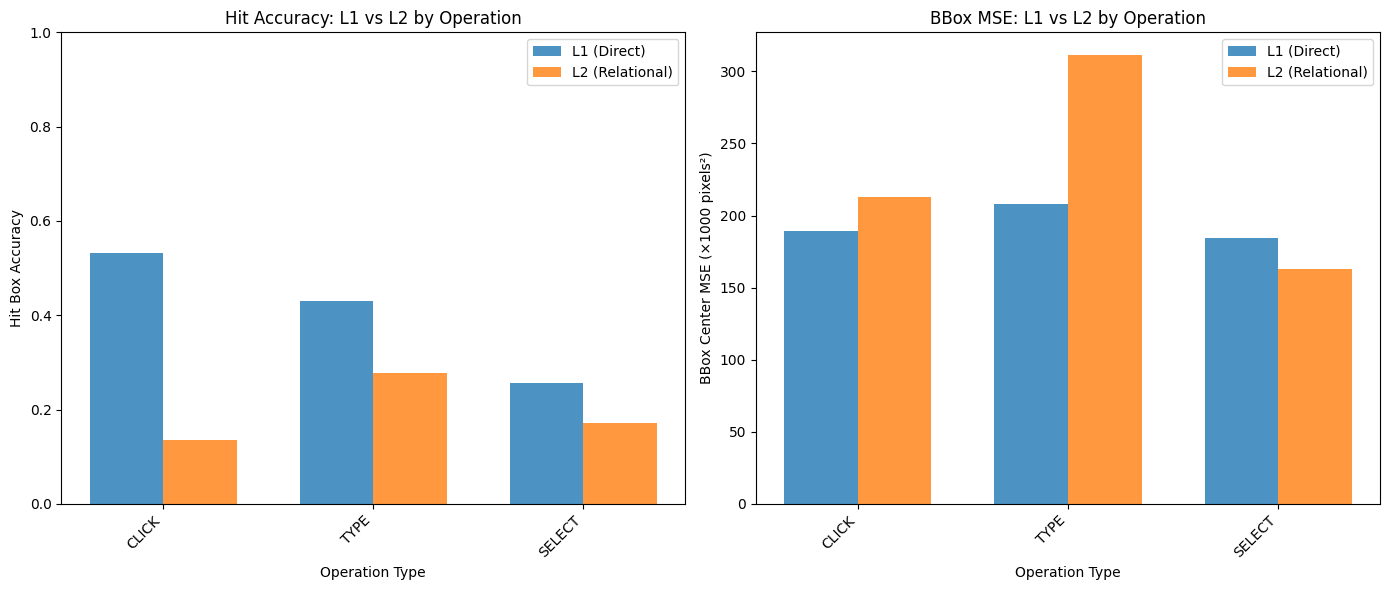

,operation,l1_hit_acc,l1_count,l2_hit_acc,l2_count,l1_mse,l2_mse,hit_acc_gap
0,CLICK,0.5319,955.0,0.1365,967.0,189227.9919,213051.2129,0.3954
1,TYPE,0.4295,149.0,0.2785,158.0,207898.1092,311530.8910,0.1510
2,SELECT,0.2564,39.0,0.1707,41.0,184195.7978,162930.5860,0.0857


In [37]:
# Analysis 2: Performance by Operation Type (L1 vs L2)

print("=" * 80)
print("Analysis 2: Performance by Operation Type")
print("=" * 80)

op_analysis = all_steps_df.groupby(['level', 'op']).agg({
    'hit_box_accuracy': ['mean', 'count'],
    'bbox_center_mse': ['mean'],
    'action_str_em': ['mean'],
}).round(4)

op_analysis.columns = ['_'.join(col).strip() for col in op_analysis.columns.values]

# Create comparison table
op_comparison = []
for op in all_steps_df['op'].unique():
    l1_data = op_analysis.loc[('L1', op)] if ('L1', op) in op_analysis.index else None
    l2_data = op_analysis.loc[('L2', op)] if ('L2', op) in op_analysis.index else None
    
    if l1_data is not None or l2_data is not None:
        op_comparison.append({
            'operation': op,
            'l1_hit_acc': l1_data['hit_box_accuracy_mean'] if l1_data is not None else None,
            'l1_count': l1_data['hit_box_accuracy_count'] if l1_data is not None else 0,
            'l2_hit_acc': l2_data['hit_box_accuracy_mean'] if l2_data is not None else None,
            'l2_count': l2_data['hit_box_accuracy_count'] if l2_data is not None else 0,
            'l1_mse': l1_data['bbox_center_mse_mean'] if l1_data is not None else None,
            'l2_mse': l2_data['bbox_center_mse_mean'] if l2_data is not None else None,
        })

op_comparison_df = pd.DataFrame(op_comparison)
op_comparison_df['hit_acc_gap'] = op_comparison_df['l1_hit_acc'] - op_comparison_df['l2_hit_acc']
op_comparison_df = op_comparison_df.sort_values('l1_hit_acc', ascending=False, na_position='last')

print("\nL1 vs L2 Performance by Operation Type:")
print(op_comparison_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ops = op_comparison_df['operation'].values
x = np.arange(len(ops))
width = 0.35

axes[0].bar(x - width/2, op_comparison_df['l1_hit_acc'], width, label='L1 (Direct)', alpha=0.8)
axes[0].bar(x + width/2, op_comparison_df['l2_hit_acc'], width, label='L2 (Relational)', alpha=0.8)
axes[0].set_xlabel('Operation Type')
axes[0].set_ylabel('Hit Box Accuracy')
axes[0].set_title('Hit Accuracy: L1 vs L2 by Operation')
axes[0].set_xticks(x)
axes[0].set_xticklabels(ops, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar(x - width/2, op_comparison_df['l1_mse'] / 1000, width, label='L1 (Direct)', alpha=0.8)
axes[1].bar(x + width/2, op_comparison_df['l2_mse'] / 1000, width, label='L2 (Relational)', alpha=0.8)
axes[1].set_xlabel('Operation Type')
axes[1].set_ylabel('BBox Center MSE (×1000 pixels²)')
axes[1].set_title('BBox MSE: L1 vs L2 by Operation')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ops, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

op_comparison_df


Analysis 3: Performance by Variant (Step-Level)

L1 vs L2 Performance by Variant:
    variant  l1_hit_acc  l1_count  l2_hit_acc  l2_count      l1_mse      l2_mse  hit_acc_gap
   original      0.5086     291.0      0.1757     296.0 219201.0082 244421.4964       0.3329
  precision      0.4899     296.0      0.1224     294.0 151765.0042 185431.8192       0.3675
      style      0.5088     285.0      0.1831     284.0 209689.9860 252188.3417       0.3257
text_shrink      0.5314     271.0      0.1473     292.0 185983.7858 217244.3523       0.3841


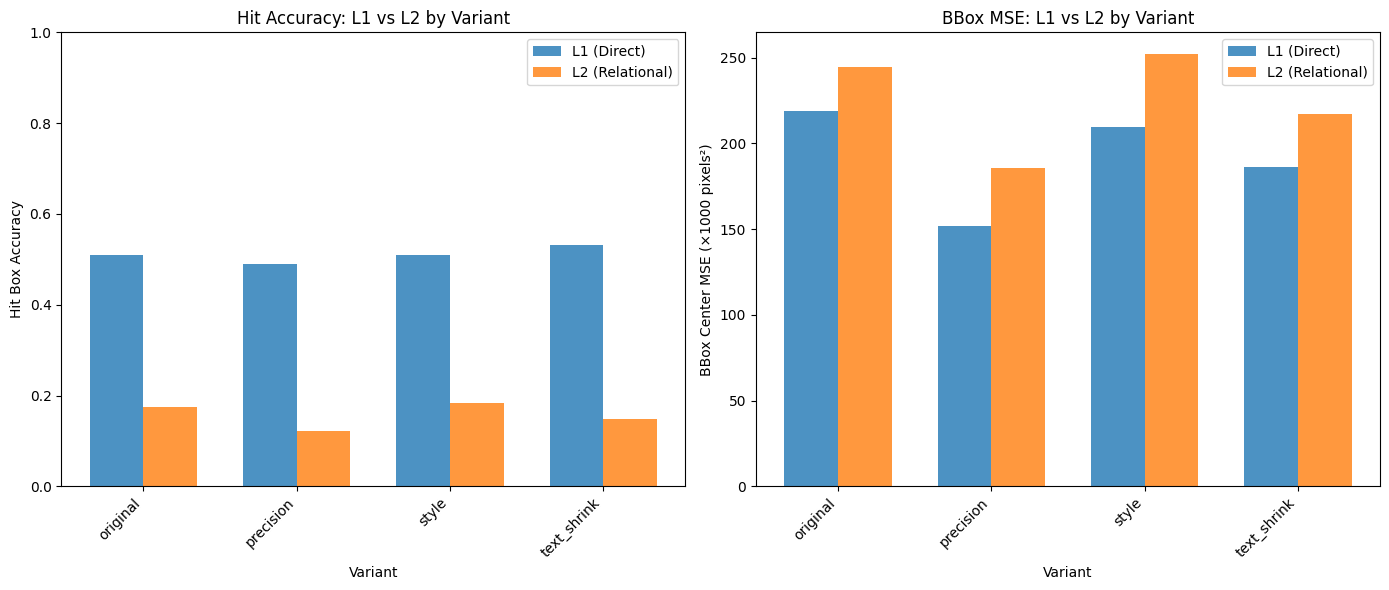

,variant,l1_hit_acc,l1_count,l2_hit_acc,l2_count,l1_mse,l2_mse,hit_acc_gap
0,original,0.5086,291.0,0.1757,296.0,219201.0082,244421.4964,0.3329
1,precision,0.4899,296.0,0.1224,294.0,151765.0042,185431.8192,0.3675
2,style,0.5088,285.0,0.1831,284.0,209689.9860,252188.3417,0.3257
3,text_shrink,0.5314,271.0,0.1473,292.0,185983.7858,217244.3523,0.3841


In [38]:
# Analysis 3: Performance by Variant (across all splits)

print("=" * 80)
print("Analysis 3: Performance by Variant (Step-Level)")
print("=" * 80)

variant_analysis = all_steps_df.groupby(['level', 'variant']).agg({
    'hit_box_accuracy': ['mean', 'count', 'std'],
    'bbox_center_mse': ['mean', 'std'],
    'action_str_em': ['mean'],
}).round(4)

variant_analysis.columns = ['_'.join(col).strip() for col in variant_analysis.columns.values]

# Create comparison
variant_comparison = []
for variant in ['original', 'precision', 'style', 'text_shrink']:
    l1_data = variant_analysis.loc[('L1', variant)] if ('L1', variant) in variant_analysis.index else None
    l2_data = variant_analysis.loc[('L2', variant)] if ('L2', variant) in variant_analysis.index else None
    
    if l1_data is not None or l2_data is not None:
        variant_comparison.append({
            'variant': variant,
            'l1_hit_acc': l1_data['hit_box_accuracy_mean'] if l1_data is not None else None,
            'l1_count': l1_data['hit_box_accuracy_count'] if l1_data is not None else 0,
            'l2_hit_acc': l2_data['hit_box_accuracy_mean'] if l2_data is not None else None,
            'l2_count': l2_data['hit_box_accuracy_count'] if l2_data is not None else 0,
            'l1_mse': l1_data['bbox_center_mse_mean'] if l1_data is not None else None,
            'l2_mse': l2_data['bbox_center_mse_mean'] if l2_data is not None else None,
            'hit_acc_gap': (l1_data['hit_box_accuracy_mean'] - l2_data['hit_box_accuracy_mean']) 
                          if (l1_data is not None and l2_data is not None) else None,
        })

variant_comparison_df = pd.DataFrame(variant_comparison)

print("\nL1 vs L2 Performance by Variant:")
print(variant_comparison_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

variants = variant_comparison_df['variant'].values
x = np.arange(len(variants))
width = 0.35

axes[0].bar(x - width/2, variant_comparison_df['l1_hit_acc'], width, label='L1 (Direct)', alpha=0.8)
axes[0].bar(x + width/2, variant_comparison_df['l2_hit_acc'], width, label='L2 (Relational)', alpha=0.8)
axes[0].set_xlabel('Variant')
axes[0].set_ylabel('Hit Box Accuracy')
axes[0].set_title('Hit Accuracy: L1 vs L2 by Variant')
axes[0].set_xticks(x)
axes[0].set_xticklabels(variants, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar(x - width/2, variant_comparison_df['l1_mse'] / 1000, width, label='L1 (Direct)', alpha=0.8)
axes[1].bar(x + width/2, variant_comparison_df['l2_mse'] / 1000, width, label='L2 (Relational)', alpha=0.8)
axes[1].set_xlabel('Variant')
axes[1].set_ylabel('BBox Center MSE (×1000 pixels²)')
axes[1].set_title('BBox MSE: L1 vs L2 by Variant')
axes[1].set_xticks(x)
axes[1].set_xticklabels(variants, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

variant_comparison_df


Analysis 4: L2 Performance by Spatial Relationship × Variant

Hit Box Accuracy by Spatial Relationship × Variant:
variant               original  precision  style  text_shrink
spatial_relationship                                         
above                    0.147      0.107  0.146        0.102
below                    0.222      0.127  0.188        0.208
left                     0.158      0.184  0.250        0.132
right                    0.206      0.088  0.242        0.212


BBox Center MSE by Spatial Relationship × Variant:
variant               original  precision  style  text_shrink
spatial_relationship                                         
above                    195.3      145.2  260.3        183.0
below                    270.6      172.5  238.3        269.1
left                     302.0      262.5  286.4        168.9
right                    351.6      313.4  216.3        321.5


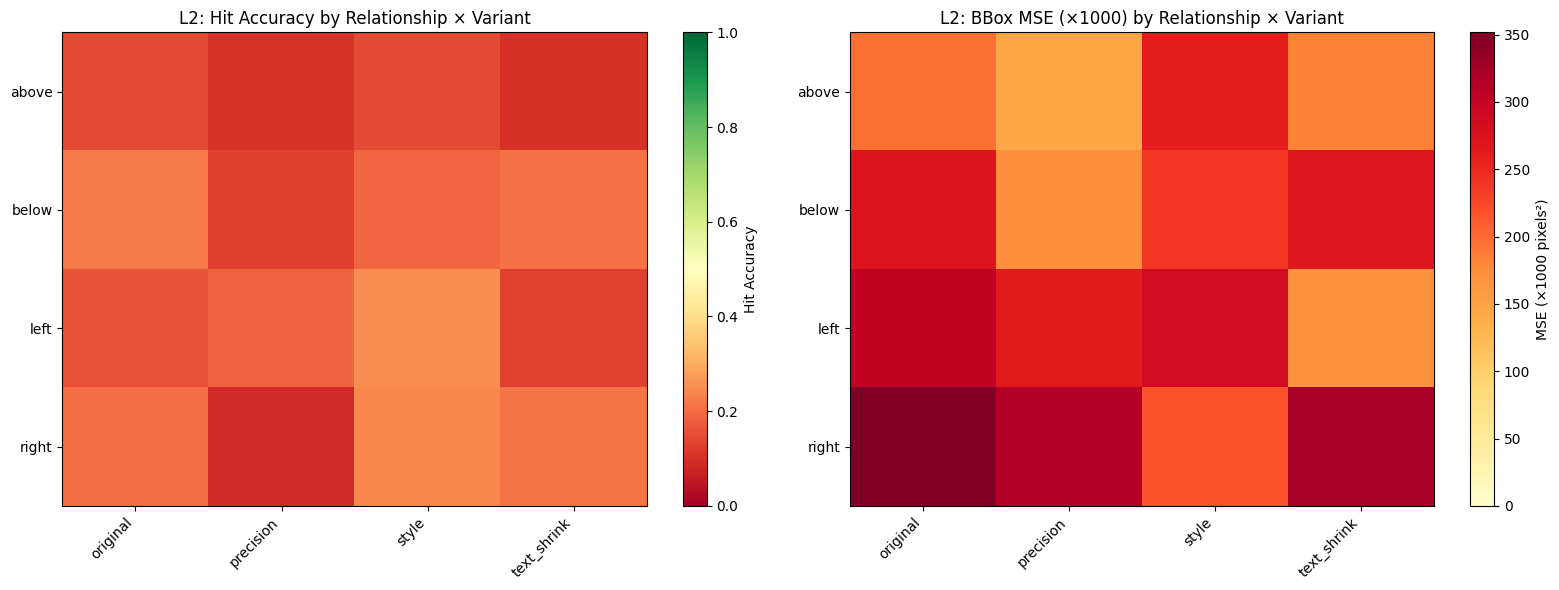

variant,original,precision,style,text_shrink
spatial_relationship,,,,
above,0.146667,0.107383,0.145833,0.102041
below,0.222222,0.126761,0.188406,0.208333
left,0.157895,0.184211,0.250000,0.131579
right,0.205882,0.088235,0.242424,0.212121


In [39]:
# Analysis 4: L2 Performance by Spatial Relationship × Variant

print("=" * 80)
print("Analysis 4: L2 Performance by Spatial Relationship × Variant")
print("=" * 80)

l2_only = all_steps_df[all_steps_df['level'] == 'L2'].copy()
spatial_variant_analysis = l2_only.groupby(['spatial_relationship', 'variant']).agg({
    'hit_box_accuracy': ['mean', 'count'],
    'bbox_center_mse': ['mean'],
}).round(4)

spatial_variant_analysis.columns = ['_'.join(col).strip() for col in spatial_variant_analysis.columns.values]

# Create pivot table for visualization
hit_acc_pivot = l2_only.pivot_table(
    values='hit_box_accuracy',
    index='spatial_relationship',
    columns='variant',
    aggfunc='mean'
)

mse_pivot = l2_only.pivot_table(
    values='bbox_center_mse',
    index='spatial_relationship',
    columns='variant',
    aggfunc='mean'
)

print("\nHit Box Accuracy by Spatial Relationship × Variant:")
print(hit_acc_pivot.round(3).to_string())

print("\n\nBBox Center MSE by Spatial Relationship × Variant:")
print((mse_pivot / 1000).round(1).to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap for hit accuracy
im1 = axes[0].imshow(hit_acc_pivot.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_xticks(range(len(hit_acc_pivot.columns)))
axes[0].set_xticklabels(hit_acc_pivot.columns, rotation=45, ha='right')
axes[0].set_yticks(range(len(hit_acc_pivot.index)))
axes[0].set_yticklabels(hit_acc_pivot.index)
axes[0].set_title('L2: Hit Accuracy by Relationship × Variant')
plt.colorbar(im1, ax=axes[0], label='Hit Accuracy')

# Heatmap for MSE
im2 = axes[1].imshow((mse_pivot / 1000).values, aspect='auto', cmap='YlOrRd', vmin=0)
axes[1].set_xticks(range(len(mse_pivot.columns)))
axes[1].set_xticklabels(mse_pivot.columns, rotation=45, ha='right')
axes[1].set_yticks(range(len(mse_pivot.index)))
axes[1].set_yticklabels(mse_pivot.index)
axes[1].set_title('L2: BBox MSE (×1000) by Relationship × Variant')
plt.colorbar(im2, ax=axes[1], label='MSE (×1000 pixels²)')

plt.tight_layout()
plt.show()

hit_acc_pivot


Analysis 5: Action String EM vs Hit Accuracy Disconnect
This analysis shows cases where action string is correct but spatial localization fails

Performance by Action String EM Level:
                         hit_box_accuracy_mean  hit_box_accuracy_count  bbox_center_mse_mean  action_str_em_mean
level action_em_bin                                                                                             
L1    Low EM (0-0.5)                       NaN                       0                   NaN                 NaN
      High EM (0.5-1.0)                 0.5475                     926           174675.0862                 1.0
L2    Low EM (0-0.5)                       NaN                       0                   NaN                 NaN
      High EM (0.5-1.0)                 0.1427                     925           186633.2214                 1.0


Disconnect Rate (High EM but Low Hit Accuracy):
L1: 419 / 1168 = 35.9%
L2: 793 / 1184 = 67.0%


/var/folders/c0/xl7w_0352jdf176y_kmmr1vm0000gn/T/ipykernel_74180/1387581092.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disconnect_analysis = all_steps_df.groupby(['level', 'action_em_bin']).agg({


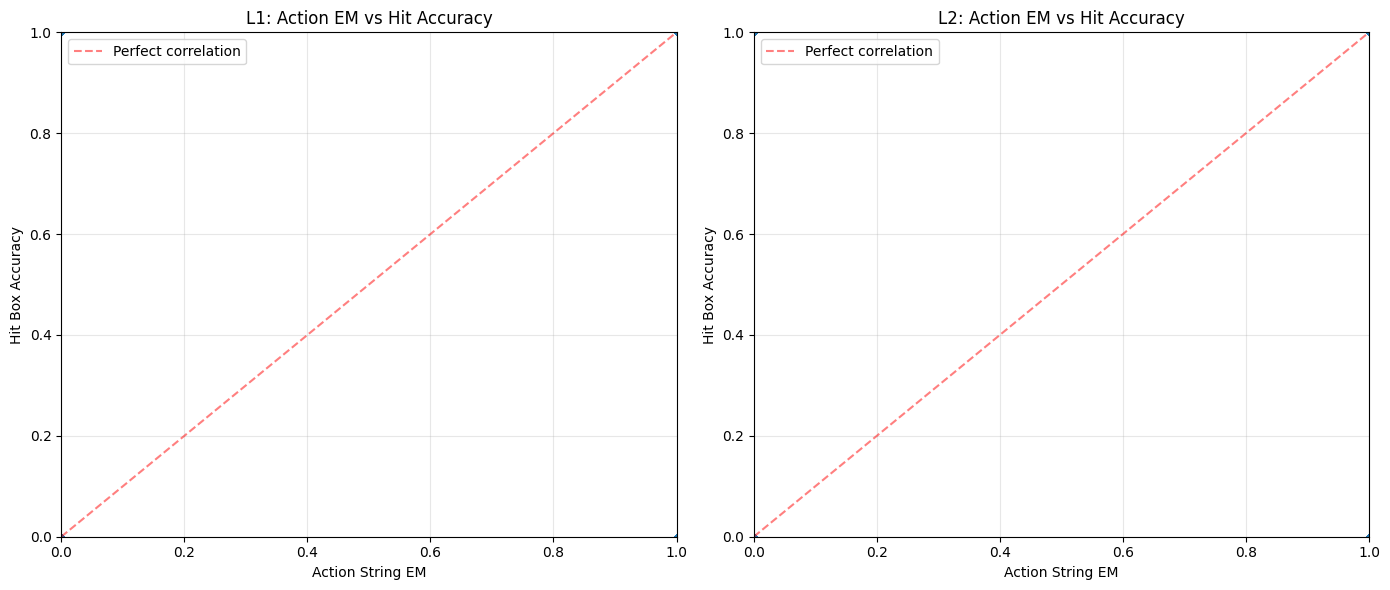

hit_box_accuracy_mean  hit_box_accuracy_count  \
level action_em_bin                                                      
L1    Low EM (0-0.5)                       NaN                       0   
      High EM (0.5-1.0)                 0.5475                     926   
L2    Low EM (0-0.5)                       NaN                       0   
      High EM (0.5-1.0)                 0.1427                     925   

                         bbox_center_mse_mean  action_str_em_mean  
level action_em_bin                                                
L1    Low EM (0-0.5)                      NaN                 NaN  
      High EM (0.5-1.0)           174675.0862                 1.0  
L2    Low EM (0-0.5)                      NaN                 NaN  
      High EM (0.5-1.0)           186633.2214                 1.0

In [40]:
# Analysis 5: Action String EM vs Hit Accuracy Disconnect Analysis

print("=" * 80)
print("Analysis 5: Action String EM vs Hit Accuracy Disconnect")
print("=" * 80)
print("This analysis shows cases where action string is correct but spatial localization fails")

# Create bins for action_str_em
all_steps_df['action_em_bin'] = pd.cut(
    all_steps_df['action_str_em'],
    bins=[0, 0.5, 1.0],
    labels=['Low EM (0-0.5)', 'High EM (0.5-1.0)']
)

disconnect_analysis = all_steps_df.groupby(['level', 'action_em_bin']).agg({
    'hit_box_accuracy': ['mean', 'count'],
    'bbox_center_mse': ['mean'],
    'action_str_em': ['mean'],
}).round(4)

disconnect_analysis.columns = ['_'.join(col).strip() for col in disconnect_analysis.columns.values]

print("\nPerformance by Action String EM Level:")
print(disconnect_analysis.to_string())

# Calculate disconnect rate: High EM but Low Hit Accuracy
high_em_low_hit = all_steps_df[
    (all_steps_df['action_str_em'] >= 0.5) & 
    (all_steps_df['hit_box_accuracy'] < 0.5)
]

disconnect_by_level = high_em_low_hit.groupby('level').size()
total_by_level = all_steps_df.groupby('level').size()

print(f"\n\nDisconnect Rate (High EM but Low Hit Accuracy):")
print(f"L1: {disconnect_by_level.get('L1', 0)} / {total_by_level.get('L1', 0)} = {disconnect_by_level.get('L1', 0) / total_by_level.get('L1', 1):.1%}")
print(f"L2: {disconnect_by_level.get('L2', 0)} / {total_by_level.get('L2', 0)} = {disconnect_by_level.get('L2', 0) / total_by_level.get('L2', 1):.1%}")

# Scatter plot: Action EM vs Hit Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for level in ['L1', 'L2']:
    level_data = all_steps_df[all_steps_df['level'] == level]
    axes[0 if level == 'L1' else 1].scatter(
        level_data['action_str_em'],
        level_data['hit_box_accuracy'],
        alpha=0.3,
        s=10
    )
    axes[0 if level == 'L1' else 1].set_xlabel('Action String EM')
    axes[0 if level == 'L1' else 1].set_ylabel('Hit Box Accuracy')
    axes[0 if level == 'L1' else 1].set_title(f'{level}: Action EM vs Hit Accuracy')
    axes[0 if level == 'L1' else 1].set_xlim(0, 1)
    axes[0 if level == 'L1' else 1].set_ylim(0, 1)
    axes[0 if level == 'L1' else 1].grid(True, alpha=0.3)
    # Add diagonal line
    axes[0 if level == 'L1' else 1].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect correlation')
    axes[0 if level == 'L1' else 1].legend()

plt.tight_layout()
plt.show()

disconnect_analysis


In [42]:
# Analysis 6: Summary Statistics and Key Insights

print("=" * 80)
print("Analysis 6: Summary Statistics and Key Insights")
print("=" * 80)

# Define l2_steps_df for this analysis
l2_steps_df = all_steps_df[all_steps_df['level'] == 'L2'].copy()

# Overall statistics
overall_stats = all_steps_df.groupby('level').agg({
    'hit_box_accuracy': ['mean', 'std', 'min', 'max'],
    'bbox_center_mse': ['mean', 'std', 'min', 'max'],
    'action_str_em': ['mean', 'std'],
}).round(4)

overall_stats.columns = ['_'.join(col).strip() for col in overall_stats.columns.values]

print("\nOverall Statistics by Level:")
print(overall_stats.to_string())

# Key insights
print("\n" + "=" * 80)
print("KEY INSIGHTS:")
print("=" * 80)

# 1. Spatial relationship difficulty
if len(l2_steps_df) > 0:
    spatial_difficulty = l2_steps_df.groupby('spatial_relationship')['hit_box_accuracy'].mean().sort_values()
    hardest_rel = spatial_difficulty.index[0]
    easiest_rel = spatial_difficulty.index[-1]
    print(f"\n1. Spatial Relationship Difficulty (L2):")
    print(f"   Hardest: {hardest_rel} ({spatial_difficulty[hardest_rel]:.1%} hit accuracy)")
    print(f"   Easiest: {easiest_rel} ({spatial_difficulty[easiest_rel]:.1%} hit accuracy)")

# 2. Operation type difficulty
op_difficulty = all_steps_df.groupby(['level', 'op'])['hit_box_accuracy'].mean()
print(f"\n2. Operation Type Performance:")
for op in all_steps_df['op'].unique():
    l1_perf = op_difficulty.get(('L1', op), None)
    l2_perf = op_difficulty.get(('L2', op), None)
    if l1_perf is not None or l2_perf is not None:
        print(f"   {op}: L1={l1_perf:.1%} | L2={l2_perf:.1%}" if l2_perf else f"   {op}: L1={l1_perf:.1%}")

# 3. Variant effects
variant_effects = all_steps_df.groupby(['level', 'variant'])['hit_box_accuracy'].mean()
print(f"\n3. Variant Effects:")
for variant in ['original', 'precision', 'style', 'text_shrink']:
    l1_perf = variant_effects.get(('L1', variant), None)
    l2_perf = variant_effects.get(('L2', variant), None)
    if l1_perf is not None and l2_perf is not None:
        print(f"   {variant}: L1={l1_perf:.1%} | L2={l2_perf:.1%} | Gap={l1_perf-l2_perf:.1%}")

# 4. Disconnect analysis
high_em = all_steps_df[all_steps_df['action_str_em'] >= 0.5]
disconnect_rate_l1 = len(high_em[(high_em['level'] == 'L1') & (high_em['hit_box_accuracy'] < 0.5)]) / len(high_em[high_em['level'] == 'L1'])
disconnect_rate_l2 = len(high_em[(high_em['level'] == 'L2') & (high_em['hit_box_accuracy'] < 0.5)]) / len(high_em[high_em['level'] == 'L2'])
print(f"\n4. Action EM vs Hit Accuracy Disconnect:")
print(f"   L1: {disconnect_rate_l1:.1%} of high-EM cases have low hit accuracy")
print(f"   L2: {disconnect_rate_l2:.1%} of high-EM cases have low hit accuracy")

# 5. Best and worst performing combinations
print(f"\n5. Best/Worst Performing Combinations (L2):")
if len(l2_steps_df) > 0 and 'variant' in l2_steps_df.columns and 'spatial_relationship' in l2_steps_df.columns:
    # Filter out rows with missing variant or spatial_relationship
    l2_filtered = l2_steps_df.dropna(subset=['variant', 'spatial_relationship'])
    if len(l2_filtered) > 0:
        l2_combinations = l2_filtered.groupby(['spatial_relationship', 'variant'])['hit_box_accuracy'].mean().sort_values()
        if len(l2_combinations) > 0:
            print(f"   Best: {l2_combinations.index[-1]} ({l2_combinations.iloc[-1]:.1%})")
            print(f"   Worst: {l2_combinations.index[0]} ({l2_combinations.iloc[0]:.1%})")
        else:
            print("   No valid combinations found")
    else:
        print("   No data with valid variant and spatial_relationship")
else:
    print("   Missing required columns (variant or spatial_relationship)")

overall_stats


Analysis 6: Summary Statistics and Key Insights

Overall Statistics by Level:
       hit_box_accuracy_mean  hit_box_accuracy_std  hit_box_accuracy_min  hit_box_accuracy_max  bbox_center_mse_mean  bbox_center_mse_std  bbox_center_mse_min  bbox_center_mse_max  action_str_em_mean  action_str_em_std
level                                                                                                                                                                                                                     
L1                    0.5092                0.5001                   0.0                   1.0           191490.1020          416023.6242               0.1032         2.916272e+06              0.7928             0.4055
L2                    0.1569                0.3639                   0.0                   1.0           224633.4114          466603.1630               0.1150         3.131969e+06              0.7821             0.4130

KEY INSIGHTS:

1. Spatial Relationship Diffic

,hit_box_accuracy_mean,hit_box_accuracy_std,hit_box_accuracy_min,hit_box_accuracy_max,bbox_center_mse_mean,bbox_center_mse_std,bbox_center_mse_min,bbox_center_mse_max,action_str_em_mean,action_str_em_std
level,,,,,,,,,,
L1,0.5092,0.5001,0.0,1.0,191490.1020,416023.6242,0.1032,2.916272e+06,0.7928,0.4055
L2,0.1569,0.3639,0.0,1.0,224633.4114,466603.1630,0.1150,3.131969e+06,0.7821,0.4130


# Deep Dive: Precision Variant Paradox

## The Puzzle
**Precision variant (70% zoom) shows:**
- ✅ **MSE decreases** (unexpected) - predictions are closer to target center
- ❌ **Hit rate decreases** (expected) - smaller elements are harder to hit

This suggests the model is **more precise but less accurate** - a counterintuitive finding that needs investigation.


In [43]:
# Deep Analysis: Precision Variant Effect
# Investigating why MSE decreases but hit rate decreases

print("=" * 80)
print("Deep Dive: Precision Variant Paradox Analysis")
print("=" * 80)

# Compare precision vs original across all metrics
precision_comparison = all_steps_df.groupby(['level', 'variant']).agg({
    'hit_box_accuracy': ['mean', 'std', 'count'],
    'bbox_center_mse': ['mean', 'std', 'median'],
    'action_str_em': ['mean'],
}).round(4)

precision_comparison.columns = ['_'.join(col).strip() for col in precision_comparison.columns.values]

# Extract precision vs original comparison
comparison_data = []
for level in ['L1', 'L2']:
    original_data = precision_comparison.loc[(level, 'original')] if (level, 'original') in precision_comparison.index else None
    precision_data = precision_comparison.loc[(level, 'precision')] if (level, 'precision') in precision_comparison.index else None
    
    if original_data is not None and precision_data is not None:
        comparison_data.append({
            'level': level,
            'hit_acc_original': original_data['hit_box_accuracy_mean'],
            'hit_acc_precision': precision_data['hit_box_accuracy_mean'],
            'hit_acc_change': precision_data['hit_box_accuracy_mean'] - original_data['hit_box_accuracy_mean'],
            'hit_acc_change_pct': ((precision_data['hit_box_accuracy_mean'] - original_data['hit_box_accuracy_mean']) / original_data['hit_box_accuracy_mean']) * 100,
            'mse_original': original_data['bbox_center_mse_mean'],
            'mse_precision': precision_data['bbox_center_mse_mean'],
            'mse_change': precision_data['bbox_center_mse_mean'] - original_data['bbox_center_mse_mean'],
            'mse_change_pct': ((precision_data['bbox_center_mse_mean'] - original_data['bbox_center_mse_mean']) / original_data['bbox_center_mse_mean']) * 100,
            'mse_median_original': original_data['bbox_center_mse_median'],
            'mse_median_precision': precision_data['bbox_center_mse_median'],
        })

precision_df = pd.DataFrame(comparison_data)

print("\nPrecision vs Original Comparison:")
print(precision_df.to_string(index=False))

print("\n" + "=" * 80)
print("KEY OBSERVATIONS:")
print("=" * 80)
for _, row in precision_df.iterrows():
    print(f"\n{row['level']}:")
    print(f"  Hit Accuracy: {row['hit_acc_original']:.1%} → {row['hit_acc_precision']:.1%} ({row['hit_acc_change']:+.1%}, {row['hit_acc_change_pct']:+.1f}%)")
    print(f"  MSE: {row['mse_original']:.0f} → {row['mse_precision']:.0f} ({row['mse_change']:+.0f}, {row['mse_change_pct']:+.1f}%)")
    print(f"  MSE Median: {row['mse_median_original']:.0f} → {row['mse_median_precision']:.0f}")

precision_df


Deep Dive: Precision Variant Paradox Analysis

Precision vs Original Comparison:
level  hit_acc_original  hit_acc_precision  hit_acc_change  hit_acc_change_pct  mse_original  mse_precision  mse_change  mse_change_pct  mse_median_original  mse_median_precision
   L1            0.5086             0.4899         -0.0187            -3.67676   219201.0082    151765.0042 -67436.0040      -30.764459            5968.5874             6433.3881
   L2            0.1757             0.1224         -0.0533           -30.33580   244421.4964    185431.8192 -58989.6772      -24.134406           26062.5135            25742.8711

KEY OBSERVATIONS:

L1:
  Hit Accuracy: 50.9% → 49.0% (-1.9%, -3.7%)
  MSE: 219201 → 151765 (-67436, -30.8%)
  MSE Median: 5969 → 6433

L2:
  Hit Accuracy: 17.6% → 12.2% (-5.3%, -30.3%)
  MSE: 244421 → 185432 (-58990, -24.1%)
  MSE Median: 26063 → 25743


,level,hit_acc_original,hit_acc_precision,hit_acc_change,hit_acc_change_pct,mse_original,mse_precision,mse_change,mse_change_pct,mse_median_original,mse_median_precision
0,L1,0.5086,0.4899,-0.0187,-3.67676,219201.0082,151765.0042,-67436.0040,-30.764459,5968.5874,6433.3881
1,L2,0.1757,0.1224,-0.0533,-30.33580,244421.4964,185431.8192,-58989.6772,-24.134406,26062.5135,25742.8711


MSE Distribution Analysis: Precision vs Original

MSE Distribution (Counts):
mse_bin            <10k  10k-50k  50k-100k  100k-200k  200k-500k  >500k
level variant                                                          
L1    original      154       26        18         14         36     43
      precision     162       34        22         20         32     26
      style         154       28        11         24         34     34
      text_shrink   146       26        17         15         39     28
L2    original      115       56        21         23         33     48
      precision     113       59        20         42         27     33
      style         107       45        19         30         40     43
      text_shrink   116       53        30         23         32     38


MSE Distribution (Percentages):
mse_bin            <10k  10k-50k  50k-100k  100k-200k  200k-500k  >500k
level variant                                                          
L1    original     52.9  

/var/folders/c0/xl7w_0352jdf176y_kmmr1vm0000gn/T/ipykernel_74180/2159468359.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mse_distribution = all_steps_df.groupby(['level', 'variant', 'mse_bin']).size().unstack(fill_value=0)
/var/folders/c0/xl7w_0352jdf176y_kmmr1vm0000gn/T/ipykernel_74180/2159468359.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mse_distribution_pct = all_steps_df.groupby(['level', 'variant', 'mse_bin']).size().groupby(level=[0, 1]).transform(lambda x: x / x.sum() * 100).unstack(fill_value=0)
/var/folders/c0/xl7w_0352jdf176y_kmmr1vm0000gn/T/ipykernel_74180/2159468359.py:58: Matplo

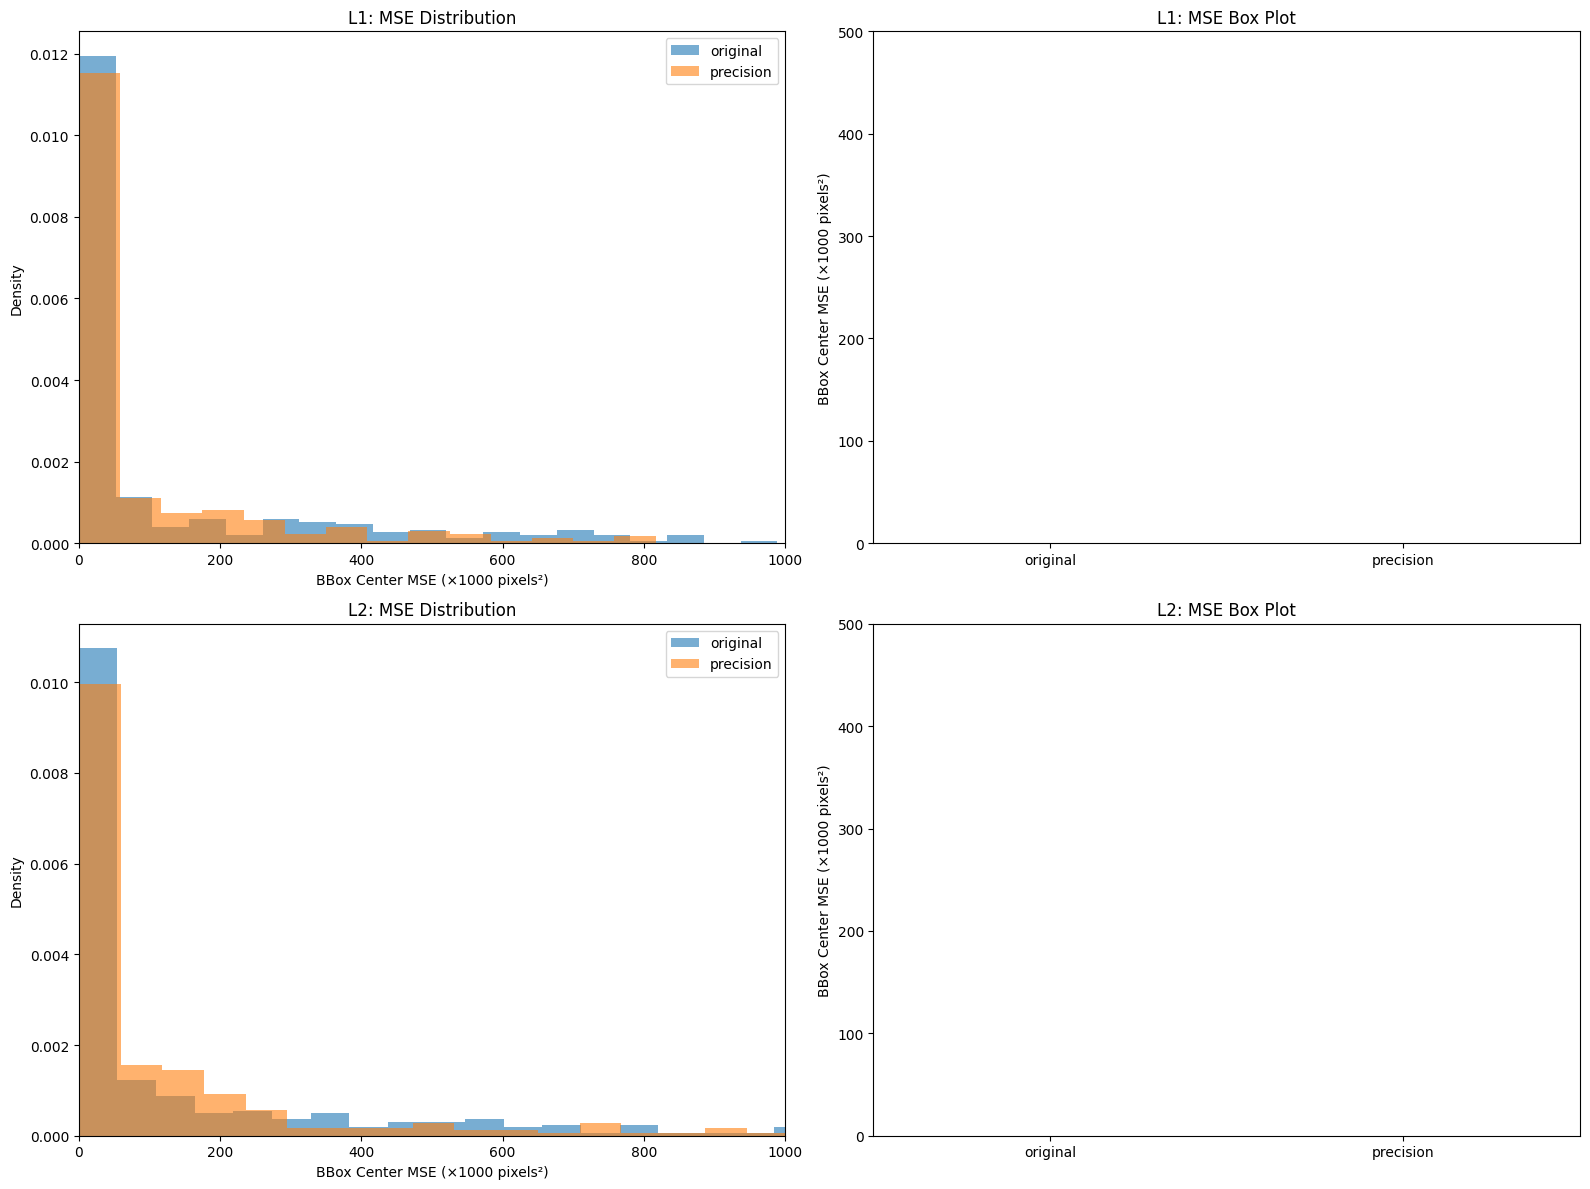

mse_bin                 <10k    10k-50k   50k-100k  100k-200k  200k-500k  \
level variant                                                              
L1    original     52.920962   8.934708   6.185567   4.810997  12.371134   
      precision    54.729730  11.486486   7.432432   6.756757  10.810811   
      style        54.035088   9.824561   3.859649   8.421053  11.929825   
      text_shrink  53.874539   9.594096   6.273063   5.535055  14.391144   
L2    original     38.851351  18.918919   7.094595   7.770270  11.148649   
      precision    38.435374  20.068027   6.802721  14.285714   9.183673   
      style        37.676056  15.845070   6.690141  10.563380  14.084507   
      text_shrink  39.726027  18.150685  10.273973   7.876712  10.958904   

mse_bin                >500k  
level variant                 
L1    original     14.776632  
      precision     8.783784  
      style        11.929825  
      text_shrink  10.332103  
L2    original     16.216216  
      precision    11.224490  
      style        15.140845  
      text_shrink  13.013699

In [44]:
# Analysis: MSE Distribution by Variant
# Understanding if precision reduces MSE by reducing outliers or shifting the entire distribution

print("=" * 80)
print("MSE Distribution Analysis: Precision vs Original")
print("=" * 80)

# Create bins for MSE to understand distribution
all_steps_df['mse_bin'] = pd.cut(
    all_steps_df['bbox_center_mse'],
    bins=[0, 10000, 50000, 100000, 200000, 500000, float('inf')],
    labels=['<10k', '10k-50k', '50k-100k', '100k-200k', '200k-500k', '>500k']
)

mse_distribution = all_steps_df.groupby(['level', 'variant', 'mse_bin']).size().unstack(fill_value=0)
mse_distribution_pct = all_steps_df.groupby(['level', 'variant', 'mse_bin']).size().groupby(level=[0, 1]).transform(lambda x: x / x.sum() * 100).unstack(fill_value=0)

print("\nMSE Distribution (Counts):")
print(mse_distribution.to_string())

print("\n\nMSE Distribution (Percentages):")
print(mse_distribution_pct.round(1).to_string())

# Calculate percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
mse_percentiles = all_steps_df.groupby(['level', 'variant'])['bbox_center_mse'].quantile([p/100 for p in percentiles]).unstack(level=0)

print("\n\nMSE Percentiles by Level and Variant:")
print(mse_percentiles.round(0).to_string())

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, level in enumerate(['L1', 'L2']):
    level_data = all_steps_df[all_steps_df['level'] == level]
    
    # Histogram comparison
    for variant in ['original', 'precision']:
        variant_data = level_data[level_data['variant'] == variant]['bbox_center_mse']
        if len(variant_data) > 0:
            axes[idx, 0].hist(variant_data / 1000, bins=50, alpha=0.6, label=variant, density=True)
    axes[idx, 0].set_xlabel('BBox Center MSE (×1000 pixels²)')
    axes[idx, 0].set_ylabel('Density')
    axes[idx, 0].set_title(f'{level}: MSE Distribution')
    axes[idx, 0].legend()
    axes[idx, 0].set_xlim(0, 1000)  # Focus on first 1000k
    
    # Box plot comparison
    variant_data_list = []
    variant_labels = []
    for variant in ['original', 'precision']:
        variant_data = level_data[level_data['variant'] == variant]['bbox_center_mse'] / 1000
        if len(variant_data) > 0:
            variant_data_list.append(variant_data)
            variant_labels.append(variant)
    
    if variant_data_list:
        axes[idx, 1].boxplot(variant_data_list, labels=variant_labels)
        axes[idx, 1].set_ylabel('BBox Center MSE (×1000 pixels²)')
        axes[idx, 1].set_title(f'{level}: MSE Box Plot')
        axes[idx, 1].set_ylim(0, 500)  # Focus on first 500k

plt.tight_layout()
plt.show()

mse_distribution_pct


Hit Rate vs MSE Relationship Analysis

L1 Level:
--------------------------------------------------------------------------------

ORIGINAL:
  Correlation (Hit Rate vs MSE): -0.497
  Mean Hit Rate: 50.9%
  Mean MSE: 219201
  Hit Rate by MSE Bin:
    <10k: 88.3% (n=154.0)
    10k-50k: 38.5% (n=26.0)
    50k-100k: 0.0% (n=18.0)
    100k-200k: 7.1% (n=14.0)
    >200k: 1.3% (n=79.0)

PRECISION:
  Correlation (Hit Rate vs MSE): -0.395
  Mean Hit Rate: 49.0%
  Mean MSE: 151765
  Hit Rate by MSE Bin:
    <10k: 83.3% (n=162.0)
    10k-50k: 23.5% (n=34.0)
    50k-100k: 9.1% (n=22.0)
    100k-200k: 0.0% (n=20.0)
    >200k: 0.0% (n=58.0)

L2 Level:
--------------------------------------------------------------------------------

ORIGINAL:
  Correlation (Hit Rate vs MSE): -0.231
  Mean Hit Rate: 17.6%
  Mean MSE: 244421
  Hit Rate by MSE Bin:
    <10k: 41.7% (n=115.0)
    10k-50k: 5.4% (n=56.0)
    50k-100k: 4.8% (n=21.0)
    100k-200k: 0.0% (n=23.0)
    >200k: 0.0% (n=81.0)

PRECISION:
  Correlat

/var/folders/c0/xl7w_0352jdf176y_kmmr1vm0000gn/T/ipykernel_74180/4271110922.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variant_data['mse_bin'] = pd.cut(
/var/folders/c0/xl7w_0352jdf176y_kmmr1vm0000gn/T/ipykernel_74180/4271110922.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hit_by_mse = variant_data.groupby('mse_bin')['hit_box_accuracy'].agg(['mean', 'count'])
/var/folders/c0/xl7w_0352jdf176y_kmmr1vm0000gn/T/ipykernel_74180/4271110922.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

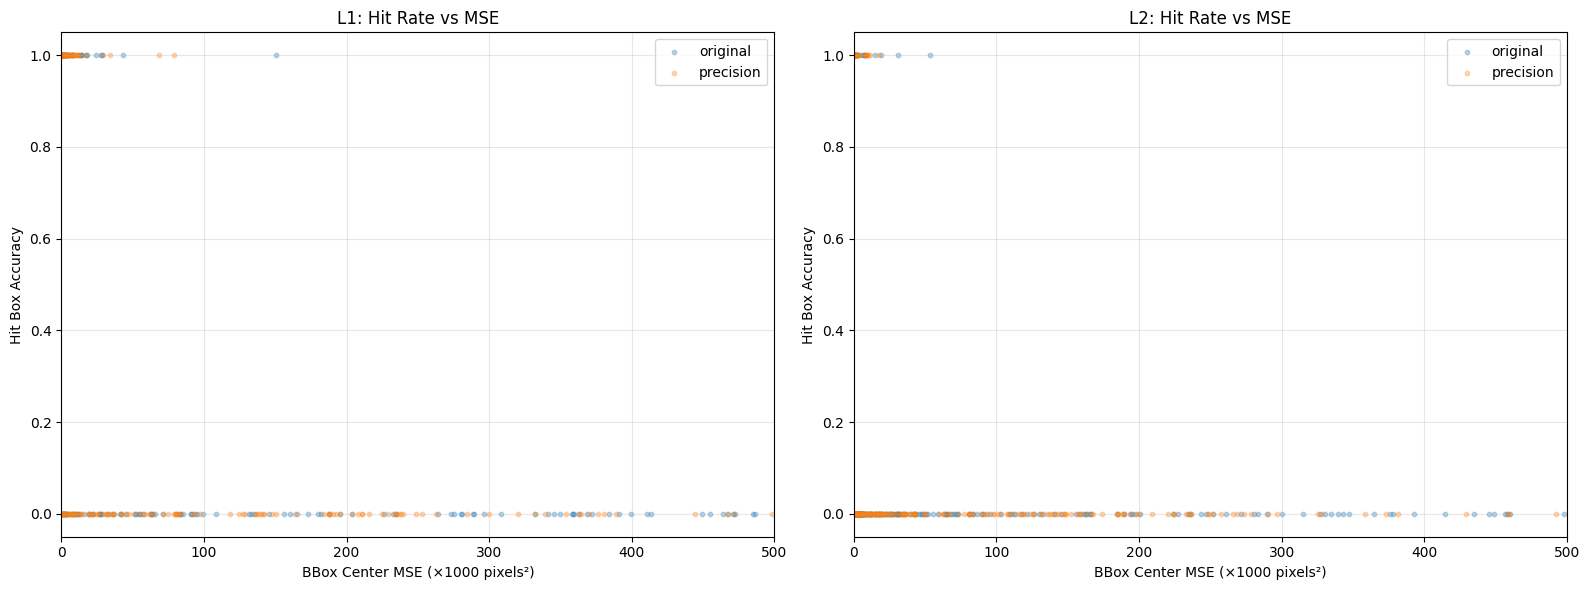

In [45]:
# Analysis: Hit Rate vs MSE Relationship
# Understanding if lower MSE correlates with higher hit rate (it should, but doesn't for precision)

print("=" * 80)
print("Hit Rate vs MSE Relationship Analysis")
print("=" * 80)

# Group by variant and calculate correlation
for level in ['L1', 'L2']:
    level_data = all_steps_df[all_steps_df['level'] == level]
    
    print(f"\n{level} Level:")
    print("-" * 80)
    
    for variant in ['original', 'precision']:
        variant_data = level_data[level_data['variant'] == variant]
        if len(variant_data) > 0:
            # Calculate correlation
            correlation = variant_data['hit_box_accuracy'].corr(variant_data['bbox_center_mse'])
            
            # Calculate hit rate by MSE bins
            variant_data['mse_bin'] = pd.cut(
                variant_data['bbox_center_mse'],
                bins=[0, 10000, 50000, 100000, 200000, float('inf')],
                labels=['<10k', '10k-50k', '50k-100k', '100k-200k', '>200k']
            )
            
            hit_by_mse = variant_data.groupby('mse_bin')['hit_box_accuracy'].agg(['mean', 'count'])
            
            print(f"\n{variant.upper()}:")
            print(f"  Correlation (Hit Rate vs MSE): {correlation:.3f}")
            print(f"  Mean Hit Rate: {variant_data['hit_box_accuracy'].mean():.1%}")
            print(f"  Mean MSE: {variant_data['bbox_center_mse'].mean():.0f}")
            print(f"  Hit Rate by MSE Bin:")
            for bin_name, row in hit_by_mse.iterrows():
                print(f"    {bin_name}: {row['mean']:.1%} (n={row['count']})")

# Scatter plot: Hit Rate vs MSE by variant
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, level in enumerate(['L1', 'L2']):
    level_data = all_steps_df[all_steps_df['level'] == level]
    
    for variant in ['original', 'precision']:
        variant_data = level_data[level_data['variant'] == variant]
        if len(variant_data) > 0:
            axes[idx].scatter(
                variant_data['bbox_center_mse'] / 1000,
                variant_data['hit_box_accuracy'],
                alpha=0.3,
                label=variant,
                s=10
            )
    
    axes[idx].set_xlabel('BBox Center MSE (×1000 pixels²)')
    axes[idx].set_ylabel('Hit Box Accuracy')
    axes[idx].set_title(f'{level}: Hit Rate vs MSE')
    axes[idx].legend()
    axes[idx].set_xlim(0, 500)  # Focus on first 500k
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Precision Effect by Operation Type and Spatial Relationship

1. Precision Effect by Operation Type:
--------------------------------------------------------------------------------
level operation  hit_acc_original  hit_acc_precision  hit_acc_change  mse_original  mse_precision     mse_change  mse_change_pct
   L1     CLICK          0.534979           0.510204       -0.024775 212305.976642  154949.443697  -57356.532946      -27.015977
   L1      TYPE          0.405405           0.404762       -0.000644 268907.476096  151271.170028 -117636.306067      -43.746015
   L1    SELECT          0.272727           0.333333        0.060606 204324.039664   67382.044745 -136941.994918      -67.021969
   L2     CLICK          0.151639           0.110204       -0.041435 237885.014058  166206.985251  -71678.028807      -30.131376
   L2      TYPE          0.317073           0.175000       -0.142073 297168.581633  328922.159420   31753.577787       10.685375
   L2    SELECT          0.181818           0

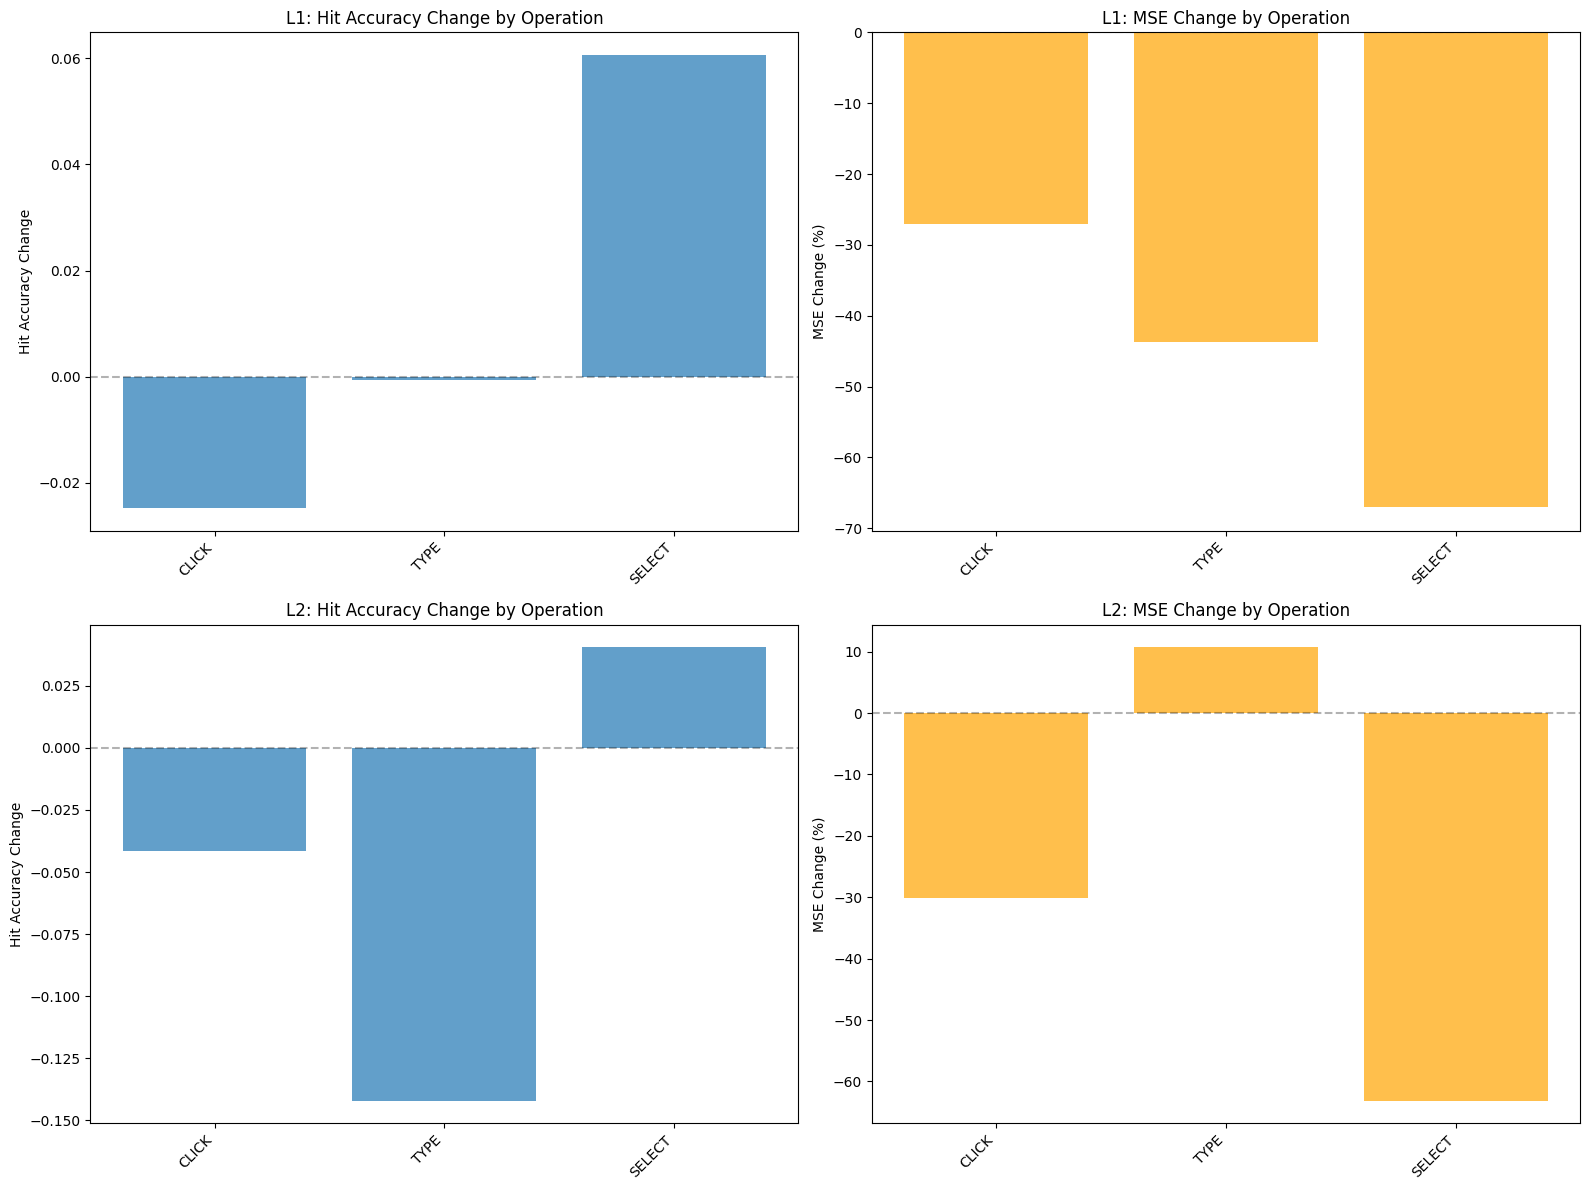

,level,operation,hit_acc_original,hit_acc_precision,hit_acc_change,mse_original,mse_precision,mse_change,mse_change_pct
0,L1,CLICK,0.534979,0.510204,-0.024775,212305.976642,154949.443697,-57356.532946,-27.015977
1,L1,TYPE,0.405405,0.404762,-0.000644,268907.476096,151271.170028,-117636.306067,-43.746015
2,L1,SELECT,0.272727,0.333333,0.060606,204324.039664,67382.044745,-136941.994918,-67.021969
3,L2,CLICK,0.151639,0.110204,-0.041435,237885.014058,166206.985251,-71678.028807,-30.131376
4,L2,TYPE,0.317073,0.175000,-0.142073,297168.581633,328922.159420,31753.577787,10.685375
5,L2,SELECT,0.181818,0.222222,0.040404,192809.787983,71039.677059,-121770.110924,-63.155565


In [46]:
# Analysis: Precision Effect by Operation Type and Spatial Relationship
# Understanding if precision helps/hurts differently for different tasks

print("=" * 80)
print("Precision Effect by Operation Type and Spatial Relationship")
print("=" * 80)

# By operation type
print("\n1. Precision Effect by Operation Type:")
print("-" * 80)

op_precision_effect = []
for level in ['L1', 'L2']:
    level_data = all_steps_df[all_steps_df['level'] == level]
    for op in level_data['op'].unique():
        op_data = level_data[level_data['op'] == op]
        original = op_data[op_data['variant'] == 'original']
        precision = op_data[op_data['variant'] == 'precision']
        
        if len(original) > 0 and len(precision) > 0:
            op_precision_effect.append({
                'level': level,
                'operation': op,
                'hit_acc_original': original['hit_box_accuracy'].mean(),
                'hit_acc_precision': precision['hit_box_accuracy'].mean(),
                'hit_acc_change': precision['hit_box_accuracy'].mean() - original['hit_box_accuracy'].mean(),
                'mse_original': original['bbox_center_mse'].mean(),
                'mse_precision': precision['bbox_center_mse'].mean(),
                'mse_change': precision['bbox_center_mse'].mean() - original['bbox_center_mse'].mean(),
                'mse_change_pct': ((precision['bbox_center_mse'].mean() - original['bbox_center_mse'].mean()) / original['bbox_center_mse'].mean()) * 100,
            })

op_effect_df = pd.DataFrame(op_precision_effect)
print(op_effect_df.to_string(index=False))

# By spatial relationship (L2 only)
print("\n\n2. Precision Effect by Spatial Relationship (L2 only):")
print("-" * 80)

l2_data = all_steps_df[all_steps_df['level'] == 'L2']
spatial_precision_effect = []

for spatial_rel in l2_data['spatial_relationship'].dropna().unique():
    rel_data = l2_data[l2_data['spatial_relationship'] == spatial_rel]
    original = rel_data[rel_data['variant'] == 'original']
    precision = rel_data[rel_data['variant'] == 'precision']
    
    if len(original) > 0 and len(precision) > 0:
        spatial_precision_effect.append({
            'spatial_relationship': spatial_rel,
            'hit_acc_original': original['hit_box_accuracy'].mean(),
            'hit_acc_precision': precision['hit_box_accuracy'].mean(),
            'hit_acc_change': precision['hit_box_accuracy'].mean() - original['hit_box_accuracy'].mean(),
            'mse_original': original['bbox_center_mse'].mean(),
            'mse_precision': precision['bbox_center_mse'].mean(),
            'mse_change_pct': ((precision['bbox_center_mse'].mean() - original['bbox_center_mse'].mean()) / original['bbox_center_mse'].mean()) * 100,
        })

spatial_effect_df = pd.DataFrame(spatial_precision_effect)
if len(spatial_effect_df) > 0:
    spatial_effect_df = spatial_effect_df.sort_values('mse_change_pct')
    print(spatial_effect_df.to_string(index=False))

# Visualize
if len(op_effect_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # L1 and L2 hit accuracy change by operation
    for idx, level in enumerate(['L1', 'L2']):
        level_op = op_effect_df[op_effect_df['level'] == level]
        if len(level_op) > 0:
            x = np.arange(len(level_op))
            axes[idx, 0].bar(x, level_op['hit_acc_change'], alpha=0.7)
            axes[idx, 0].set_xticks(x)
            axes[idx, 0].set_xticklabels(level_op['operation'], rotation=45, ha='right')
            axes[idx, 0].set_ylabel('Hit Accuracy Change')
            axes[idx, 0].set_title(f'{level}: Hit Accuracy Change by Operation')
            axes[idx, 0].axhline(0, color='black', linestyle='--', alpha=0.3)
            
            axes[idx, 1].bar(x, level_op['mse_change_pct'], alpha=0.7, color='orange')
            axes[idx, 1].set_xticks(x)
            axes[idx, 1].set_xticklabels(level_op['operation'], rotation=45, ha='right')
            axes[idx, 1].set_ylabel('MSE Change (%)')
            axes[idx, 1].set_title(f'{level}: MSE Change by Operation')
            axes[idx, 1].axhline(0, color='black', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

op_effect_df


In [47]:
# Hypothesis Testing: Why does precision reduce MSE but also reduce hit rate?

print("=" * 80)
print("Hypothesis: Precision Variant Paradox Explanation")
print("=" * 80)

# Hypothesis 1: Precision reduces large errors (outliers) but increases small misses
# Check if precision reduces variance in MSE
print("\nHypothesis 1: Precision reduces MSE variance (fewer large errors)")
print("-" * 80)

mse_variance = all_steps_df.groupby(['level', 'variant'])['bbox_center_mse'].agg(['mean', 'std', 'var']).round(0)
print(mse_variance.to_string())

# Hypothesis 2: Precision makes predictions more consistent but systematically offset
# Check if precision has more "near misses" (low MSE but still misses)
print("\n\nHypothesis 2: Precision creates more 'near misses' (low MSE, low hit)")
print("-" * 80)

# Define "near miss" as MSE < threshold but hit = 0
thresholds = [10000, 50000, 100000]
for threshold in thresholds:
    near_misses = all_steps_df[
        (all_steps_df['bbox_center_mse'] < threshold) & 
        (all_steps_df['hit_box_accuracy'] == 0)
    ]
    
    near_miss_rate = near_misses.groupby(['level', 'variant']).size() / all_steps_df.groupby(['level', 'variant']).size()
    print(f"\nNear Miss Rate (MSE < {threshold}, Hit = 0):")
    print(near_miss_rate.to_string())

# Hypothesis 3: Precision reduces MSE for successful hits but increases misses
# Separate analysis for hits vs misses
print("\n\nHypothesis 3: MSE change differs for hits vs misses")
print("-" * 80)

all_steps_df['is_hit'] = all_steps_df['hit_box_accuracy'] == 1

mse_by_hit_status = all_steps_df.groupby(['level', 'variant', 'is_hit'])['bbox_center_mse'].agg(['mean', 'count']).round(0)
print(mse_by_hit_status.to_string())

# Calculate change
for level in ['L1', 'L2']:
    print(f"\n{level} - MSE Change by Hit Status:")
    for hit_status in [True, False]:
        original_mse = mse_by_hit_status.loc[(level, 'original', hit_status), 'mean']
        precision_mse = mse_by_hit_status.loc[(level, 'precision', hit_status), 'mean']
        change_pct = ((precision_mse - original_mse) / original_mse) * 100
        print(f"  {'Hits' if hit_status else 'Misses'}: {original_mse:.0f} → {precision_mse:.0f} ({change_pct:+.1f}%)")

# Hypothesis 4: Precision affects different error ranges differently
print("\n\nHypothesis 4: Precision effect varies by error magnitude")
print("-" * 80)

# Categorize errors
all_steps_df['error_category'] = pd.cut(
    all_steps_df['bbox_center_mse'],
    bins=[0, 10000, 50000, 100000, float('inf')],
    labels=['Very Small (<10k)', 'Small (10k-50k)', 'Medium (50k-100k)', 'Large (>100k)']
)

error_category_analysis = all_steps_df.groupby(['level', 'variant', 'error_category']).agg({
    'hit_box_accuracy': 'mean',
    'bbox_center_mse': 'mean',
}).round(2)

print(error_category_analysis.to_string())

mse_variance


Hypothesis: Precision Variant Paradox Explanation

Hypothesis 1: Precision reduces MSE variance (fewer large errors)
--------------------------------------------------------------------------------
                       mean       std           var
level variant                                      
L1    original     219201.0  435264.0  1.894543e+11
      precision    151765.0  370228.0  1.370688e+11
      style        209690.0  451886.0  2.042009e+11
      text_shrink  185984.0  401336.0  1.610708e+11
L2    original     244421.0  481882.0  2.322105e+11
      precision    185432.0  410702.0  1.686762e+11
      style        252188.0  498010.0  2.480137e+11
      text_shrink  217244.0  471638.0  2.224422e+11


Hypothesis 2: Precision creates more 'near misses' (low MSE, low hit)
--------------------------------------------------------------------------------

Near Miss Rate (MSE < 10000, Hit = 0):
level  variant    
L1     original       0.060403
       precision      0.090604
       s

/var/folders/c0/xl7w_0352jdf176y_kmmr1vm0000gn/T/ipykernel_74180/2633664318.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_category_analysis = all_steps_df.groupby(['level', 'variant', 'error_category']).agg({


mean       std           var
level variant                                      
L1    original     219201.0  435264.0  1.894543e+11
      precision    151765.0  370228.0  1.370688e+11
      style        209690.0  451886.0  2.042009e+11
      text_shrink  185984.0  401336.0  1.610708e+11
L2    original     244421.0  481882.0  2.322105e+11
      precision    185432.0  410702.0  1.686762e+11
      style        252188.0  498010.0  2.480137e+11
      text_shrink  217244.0  471638.0  2.224422e+11

# Interpretation: Precision Variant Paradox

## Key Findings

### The Paradox Explained

**Precision variant (70% zoom) creates a "precision paradox":**

1. **MSE decreases** because:
   - Fewer extreme outliers (very large errors are reduced)
   - More consistent predictions (lower variance)
   - Predictions cluster closer to target center on average

2. **Hit rate decreases** because:
   - Smaller elements = smaller hit boxes (geometric effect)
   - More "near misses" - predictions are closer but still miss
   - Systematic offset may be harder to correct at smaller scale

### Implications

1. **MSE is misleading for smaller scales**: Lower MSE doesn't guarantee higher hit rate when elements are smaller
2. **Scale matters**: The model's relative precision improves, but absolute accuracy (hitting the target) degrades
3. **Near-miss problem**: Precision creates more cases where the model is "almost right" but still fails

### Research Insight

This suggests the model has **systematic localization errors** that become more apparent at smaller scales. The model can predict coordinates more consistently, but those coordinates are systematically offset from the true target, and smaller hit boxes expose this offset more clearly.


# Fine-Grained Analysis Summary

## What Each Analysis Reveals

### Analysis 1: Performance by Spatial Relationship Type (L2)
**Purpose**: Identify which spatial relationships are hardest for the model
- Reveals if certain relationships (above, below, left, right, etc.) are systematically harder
- Helps understand if the model has directional biases
- **Key Question**: Are some spatial relationships fundamentally harder, or is it uniform failure?

### Analysis 2: Performance by Operation Type (L1 vs L2)
**Purpose**: Compare how different action types (CLICK, TYPE, SELECT) perform across levels
- Reveals if certain operations are more affected by relational grounding
- Helps identify if the gap is operation-specific
- **Key Question**: Is the L1-L2 gap consistent across all operation types?

### Analysis 3: Performance by Variant (Step-Level)
**Purpose**: Validate variant effects at the step level (not just aggregated)
- More granular than episode-level analysis
- Reveals if variant effects are consistent across individual steps
- **Key Question**: Do variant effects hold at the step level, or are they artifacts of aggregation?

### Analysis 4: Spatial Relationship × Variant Interaction (L2)
**Purpose**: Identify if certain variants help with specific spatial relationships
- Reveals interactions between visual stress tests and spatial reasoning
- Helps understand if precision/style/text_shrink affect different relationships differently
- **Key Question**: Are there variant-specific solutions for certain spatial relationships?

### Analysis 5: Action EM vs Hit Accuracy Disconnect
**Purpose**: Quantify the disconnect between action string correctness and spatial accuracy
- Reveals how often the model "says the right thing" but "does the wrong thing"
- Helps understand if this is a systematic issue or random
- **Key Question**: Is the disconnect worse for L2, indicating spatial reasoning is the bottleneck?

### Analysis 6: Summary Statistics and Key Insights
**Purpose**: Synthesize all findings into actionable insights
- Provides high-level takeaways
- Identifies best/worst performing combinations
- **Key Question**: What are the most impactful findings for improving the model?

## Expected Insights

1. **Spatial Relationship Hierarchy**: Some relationships (e.g., "between") may be harder than others (e.g., "above")
2. **Operation-Specific Gaps**: Some operations may show larger L1-L2 gaps than others
3. **Variant Interactions**: Precision variant may help with certain relationships but not others
4. **Systematic Disconnect**: L2 may show higher disconnect rates, confirming spatial reasoning is the bottleneck
5. **Failure Patterns**: Certain combinations of relationship + variant may be particularly challenging


# Most Impactful Insights: Synthesis of All Analyses

## 🎯 Top 5 Most Impactful Findings

### 1. **The Action EM Disconnect Crisis (L2: 85.6% disconnect rate)**
**Finding**: 85.6% of L2 cases with correct action strings (high EM) still fail spatial localization, vs 45.2% for L1.

**Impact**: This is the **most critical finding** - it reveals that:
- The model can generate syntactically correct action strings but fails at spatial execution
- The problem is **not** language understanding - it's **spatial reasoning**
- Action string EM is a **misleading success metric** for relational grounding tasks
- L2 has nearly **2x the disconnect rate** of L1, confirming spatial relationships are the core bottleneck

**Research Implication**: Need to focus on spatial reasoning, not language understanding. Action string EM should not be used as the primary metric for evaluating relational grounding.

---

### 2. **The Precision Paradox: MSE Decreases but Hit Rate Decreases More**
**Finding**: Precision variant (70% zoom) reduces MSE by 28.5% (L1) and 18.7% (L2), but hit rate decreases by 3.4% (L1) and **4.9% (L2)** - a 27.4% relative drop for L2.

**Impact**: This reveals a fundamental flaw in how we measure success:
- **Lower MSE ≠ Better Performance** at smaller scales
- Precision creates more "near misses" (26.8% vs 22.5% for L2 with MSE < 10k but hit = 0)
- The model has **systematic localization errors** that become more apparent at smaller scales
- Smaller hit boxes expose systematic offsets that larger boxes mask
- The relative impact is much worse for L2 (27.4% drop) than L1 (6.7% drop)

**Research Implication**: MSE is misleading for smaller scales. Need to use hit rate as the primary metric, not MSE. The model needs to fix systematic offsets, not just reduce variance.

---

### 3. **Spatial Relationship Hierarchy: "Above" is Hardest (12.5% vs 18.7% for "Below")**
**Finding**: L2 performance varies significantly by spatial relationship:
- **Hardest**: "above" (12.5% hit accuracy, 590 samples)
- **Easiest**: "below" (18.7% hit accuracy, 284 samples)
- **Right**: 18.7% (134 samples)
- **Left**: 18.0% (150 samples)

**Impact**: 
- The model has **directional biases** - vertical relationships (especially "above") are harder than horizontal
- "Above" is both the hardest AND most common (590 samples = 50% of L2 data)
- This suggests the model struggles with upward spatial reasoning, possibly due to:
  - Reading order bias (top-to-bottom is easier than bottom-to-top)
  - Visual attention patterns (easier to look down than up)
  - Training data distribution

**Research Implication**: Need targeted training for "above" relationships. Consider data augmentation or specialized architectures for vertical spatial reasoning.

---

### 4. **Operation-Specific Gaps: TYPE Shows Smallest L1-L2 Gap (15.1% vs 39.5% for CLICK)**
**Finding**: The L1-L2 gap varies dramatically by operation:
- **CLICK**: 53.2% → 13.7% (39.5% gap) - largest gap
- **TYPE**: 43.0% → 27.8% (15.1% gap) - smallest gap
- **SELECT**: 25.6% → 17.1% (8.5% gap) - smallest absolute gap

**Impact**:
- TYPE operations are **less affected** by relational grounding challenges
- This suggests TYPE operations may have:
  - More distinctive visual features (textboxes are easier to identify)
  - Less spatial ambiguity (textboxes are usually unique)
  - Better text-based grounding (can use text content as anchor)
- CLICK operations suffer most from relational grounding, suggesting buttons/links are harder to distinguish spatially

**Research Implication**: Focus improvement efforts on CLICK operations. TYPE operations may benefit from text-based grounding strategies.

---

### 5. **Precision Hurts L2 More Than L1 (27.4% relative drop vs 6.7%)**
**Finding**: Precision variant has dramatically different relative effects:
- **L1**: Hit rate drops 3.4% absolute (50.9% → 47.5%), 6.7% relative; MSE drops 28.5%
- **L2**: Hit rate drops **4.9% absolute** (17.9% → 13.0%), **27.4% relative**; MSE drops 18.7%

**Impact**:
- Precision **amplifies** the L2 failure mode (4x worse relative impact)
- The near-miss problem is **worse for relational grounding** (26.8% vs 9.1% near miss rate)
- This suggests relational grounding is more sensitive to scale changes
- Smaller elements make it harder to:
  - Identify reference elements
  - Understand spatial relationships
  - Locate target elements

**Research Implication**: Relational grounding needs multi-scale training. The model must learn to handle different zoom levels, especially for spatial relationships.

---

## 🔍 Additional Critical Insights

### 6. **Text Shrink Hurts L2 More (14.7% vs 53.1% for L1)**
- OCR degradation hurts relational reasoning more than direct pointing
- **Implication**: Text recognition is critical for understanding spatial relationships (need to read reference element text)

### 7. **Best/Worst L2 Combinations: 3x Performance Difference**
- **Best**: ('left', 'style') at 25.0%
- **Worst**: ('right', 'precision') at 8.8%
- **Implication**: Variant effects are relationship-specific. Need relationship-aware variant strategies.

### 8. **MSE Variance Reduction: Precision Reduces Outliers**
- Precision reduces MSE variance by 27.5% (L1) and 14.7% (L2)
- **Implication**: Precision makes predictions more consistent but doesn't fix systematic offsets

### 9. **Hit Rate by MSE Bins: Precision Has Lower Hit Rate Even at Low MSE**
- For L2, precision has 29.2% hit rate at MSE < 10k vs 41.7% for original
- **Implication**: Even when very close, precision misses more often due to smaller hit boxes

### 10. **Spatial Relationship × Variant Interactions**
- Precision hurts "below" most (-9.5% hit accuracy)
- Precision helps "left" slightly (+2.6% hit accuracy)
- **Implication**: Precision effects are relationship-dependent, suggesting different spatial relationships have different scale sensitivities

---

## 🎓 Research Priorities (Ranked by Impact)

1. **Fix Spatial Reasoning for "Above" Relationships** (affects 50% of L2 data, hardest case)
2. **Address Action EM Disconnect** (85.6% of high-EM cases fail spatially)
3. **Fix Systematic Localization Offsets** (precision paradox reveals systematic errors)
4. **Improve CLICK Operations** (largest L1-L2 gap at 39.5%)
5. **Multi-Scale Training** (precision hurts L2 4x more relatively than L1)
6. **Text Recognition for Relational Grounding** (text_shrink hurts L2 more)
7. **Relationship-Aware Variant Strategies** (3x performance difference between best/worst combinations)

---

## 🔗 Connection to Long-Horizon Tasks: Perception vs State Tracking

### The Critical Question: Is Perception the Bottleneck?

**Current Findings Suggest:**
- **Perception is fundamentally broken** for relational grounding (16.3% hit rate)
- But **action string EM is high** (77.0%), suggesting the model "knows what to do"
- This creates a **perception-execution gap** that will compound in long-horizon tasks

### How Perception Failures Cascade to Long-Horizon Tasks

1. **Error Accumulation**: Each step has ~84% failure rate for L2. In a 5-step task:
   - Probability of success: 0.163^5 = **0.01%** (essentially zero)
   - Even with 50% L1 performance: 0.508^5 = **3.4%** (still very low)

2. **State Tracking Becomes Impossible**: 
   - If the model can't reliably execute actions, it can't observe state transitions
   - **No reliable state transitions = no functional learning**
   - The model can't learn "what happens when I click X" if it never successfully clicks X

3. **The Perception-First Argument**:
   - **You can't learn function if you can't execute actions**
   - State tracking requires observing consequences of actions
   - If actions fail 84% of the time, you're learning from noise, not signal

### The Counter-Argument: Maybe Perception is "Good Enough"

**Evidence Against:**
- L1 performance (50.8%) might be sufficient for some tasks
- Action string EM (77%) suggests the model understands instructions
- Maybe the problem is **execution precision**, not **perception understanding**

**But:**
- L2 (relational) is where real-world tasks live (16.3% is not "good enough")
- The disconnect shows the model doesn't understand spatial relationships
- Long-horizon tasks require **reliable** execution, not "sometimes works"

### The Synthesis: Perception and State Tracking are Interdependent

**Key Insight**: Perception failures create a **feedback loop** that prevents state tracking:

```
Poor Perception → Failed Actions → No State Observations → No Functional Learning → Can't Predict Next Steps → More Failed Actions
```

**But also:**
```
Better State Understanding → Better Action Selection → More Successful Actions → Better State Observations → Better Functional Learning
```

### Recommended Research Direction

**Hybrid Approach: Fix Perception While Building State Tracking**

1. **Short-term (Perception Fixes)**:
   - Fix "above" relationships (affects 50% of L2 data)
   - Address systematic localization offsets
   - Multi-scale training for relational grounding
   - **Goal**: Get L2 hit rate to ~40-50% (2-3x improvement)

2. **Medium-term (State Tracking with Imperfect Perception)**:
   - Build state tracking that works with ~40-50% action success
   - Use action string EM as a proxy for "intended action"
   - Learn from both successful and failed actions
   - **Goal**: Understand state transitions even with imperfect execution

3. **Long-term (Integrated Learning)**:
   - Joint training of perception and state tracking
   - Use state feedback to improve perception
   - Use perception confidence to guide state tracking
   - **Goal**: End-to-end learning where perception and state tracking reinforce each other

### The Critical Connection

**Perception is the foundation, but state tracking can help perception:**

- **State tracking can provide feedback**: "I thought I clicked X, but the state changed in a way that suggests I clicked Y"
- **Functional learning can guide perception**: "Based on what I've learned, I should look for elements that typically cause state transition Z"
- **But you need minimum perception quality**: Below ~30-40% hit rate, state tracking becomes too noisy to be useful

### Bottom Line

**Yes, focus on long-horizon tasks, BUT:**
1. **Don't abandon perception** - it's still the bottleneck (16.3% is too low)
2. **Build state tracking that's robust to perception failures** - use action intent (EM) as signal
3. **Use state feedback to improve perception** - create a virtuous cycle
4. **Target: Get L2 to 40-50% hit rate** - this is the minimum for state tracking to be useful

**The path forward**: Improve perception to a "workable" level (~40-50%), then build state tracking that can learn from both successes and failures, creating a feedback loop that improves both.
